In [1]:
# Practicing data cleaning on the Ames dataset
# Sibusiso Mathebula
# 10/07/2025


# Data cleaning and EDA 
This code is to showcase my data cleaning skills by performing data cleaning on the Ames Housing dataset.

It consists of the following processes:

1. Data cleaning:
  - Dropping duplicates
  - Missing value imputation
  - Dropping columns

2. Exploratory Data Analysis:
 - Average house price analysis
 - Log transformation of target feature
 - Numerical distribution of target feature
 - Correlation analysis of numerical features using the Pearsonr and Spearmanr correlation  matrix
 - Distribution of numerical feature with strong correlation with the target variable.
 - Outlier detection and analysis of the numerical features with strong correlation.

In [2]:
# Importing important libraries for data cleaning
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


In [3]:
df = pd.read_csv('AmesHousing.csv')  # import housing dataset

In [4]:
before_cols = df.columns   # original columns 

In [5]:
df.info()    # This is to find out information  about the data types in each column


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [6]:
# Changing datatype from int to categorical. The data is categorical but was saved as int64. So had to convert
df['MS SubClass'] = df['MS SubClass'].astype('object')
df['Overall Cond'] = df['Overall Cond'].astype('object')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   object 
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [7]:
df.describe()  # obtaining the summary statistics of each numerical column

,Order,PID,Lot Frontage,Lot Area,Overall Qual,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,69.224590,10147.921843,6.094881,1971.356314,1984.266553,101.896801,442.629566,49.722431,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,23.365335,7880.017759,1.411026,30.245361,20.860286,179.112611,455.590839,169.168476,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,21.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,58.000000,7440.250000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,68.000000,9436.500000,6.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,80.000000,11555.250000,7.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,313.000000,215245.000000,10.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [8]:
df.head()   # trying to get a look at how the data set looks

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [9]:
cols_missing = df.isnull().sum().sort_values(ascending = False)   # mask used for finding the number of missing values for
# each column

In [10]:
print(cols_missing[cols_missing > 0])   # number of missing values for each column

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
Garage Cars          1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Garage Area          1
dtype: int64


In [11]:
tot_missing = cols_missing[cols_missing>0].sum()  # total number of missing values for the entire dataset
print('Total number of missing : ',tot_missing)

Total number of missing :  15749


In [12]:
total_values = df.size  # total number of values for the entire dataset

In [13]:
print(f'percentage of missing values {(tot_missing/total_values)*100 : .2f} %')  # percntage of 
#     missing values compared to the entire dataset

percentage of missing values  6.55 %


This was done assuming that a column of a dataset is most likely not useful if a significant number
of values are missing values. So, the threshold of missing values for a dataset is decided to be 70%. If 70%  or greater percentage of a column is 
just missing values , then it is most likely not useful so it is dropped. The 70% threshold is a heuristic; in practice, domain knowledge (e.g. whether a feature is structural or optional) should override this rule.

In [14]:
threshold = 0.7   # threshold for the percentage of missing values in each column

In [15]:
cols_missing_fraction = cols_missing/ len(df)
print(cols_missing_fraction)   # printing percentages of missing values for each column

Pool QC         0.995563
Misc Feature    0.963823
Alley           0.932423
Fence           0.804778
Mas Vnr Type    0.605802
                  ...   
PID             0.000000
Central Air     0.000000
1st Flr SF      0.000000
2nd Flr SF      0.000000
SalePrice       0.000000
Length: 82, dtype: float64


In [16]:
cols_drop = cols_missing_fraction[cols_missing_fraction >= 0.7]
print(cols_drop.index)   # printing the columns with more than 70% proportion of missing values


Index(['Pool QC', 'Misc Feature', 'Alley', 'Fence'], dtype='object')


In [17]:
df.drop(cols_drop.index,axis=1, inplace=True)  # dropping columns with more than 70% missing values

In [18]:
df.columns  # remaining columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

In [19]:
list(set(before_cols)-set(df.columns))  # columns that have been dropped

['Fence', 'Pool QC', 'Alley', 'Misc Feature']

In [20]:
non_object_cols= df.select_dtypes(exclude='object')  
# columns with non object data (numerical data)

non_object_cols = non_object_cols.columns.tolist()

In [21]:
object_cols = df.drop(non_object_cols, axis=1)  # dataframe of object data coluimns

The missing data for categorical or object data was replaced by 'None' string . 

In [22]:
# unique values in each categorical feature

object_cols_list = object_cols.columns.tolist()
print(object_cols_list)

df[object_cols_list].nunique()

['MS SubClass', 'MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Cond', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition']


MS SubClass       16
MS Zoning          7
Street             2
Lot Shape          4
Land Contour       4
Utilities          3
Lot Config         5
Land Slope         3
Neighborhood      28
Condition 1        9
Condition 2        8
Bldg Type          5
House Style        8
Overall Cond       9
Roof Style         6
Roof Matl          8
Exterior 1st      16
Exterior 2nd      17
Mas Vnr Type       4
Exter Qual         4
Exter Cond         5
Foundation         6
Bsmt Qual          5
Bsmt Cond          5
Bsmt Exposure      4
BsmtFin Type 1     6
BsmtFin Type 2     6
Heating            6
Heating QC         5
Central Air        2
Electrical         5
Kitchen Qual       5
Functional         8
Fireplace Qu       5
Garage Type        6
Garage Finish      3
Garage Qual        5
Garage Cond        5
Paved Drive        3
Sale Type         10
Sale Condition     6
dtype: int64

In [23]:
df.drop_duplicates()  # dropping duplicates

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,IR1,Low,AllPub,...,0,0,0,0,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,...,0,0,0,0,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2006,WD,Normal,170000


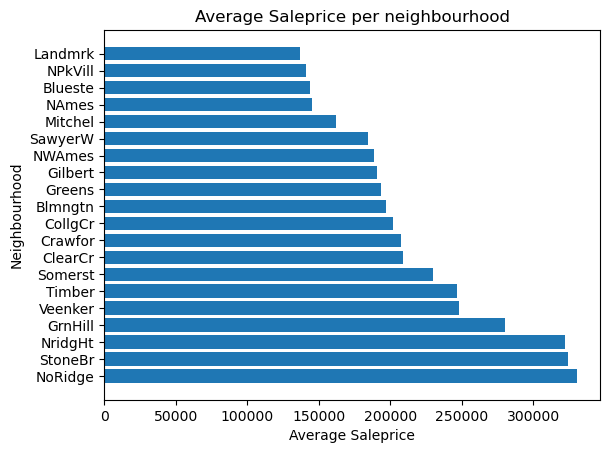

In [24]:
df_by_neighbourhood = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(20).reset_index(name='SalePrice')

plt.figure()
plt.barh(df_by_neighbourhood['Neighborhood'],df_by_neighbourhood['SalePrice'])

plt.xlabel('Average Saleprice')
plt.ylabel('Neighbourhood')
plt.title('Average Saleprice per neighbourhood')
plt.show()

The neighbourhood with the greatest average price of housing is the NoRidge neighbourhood.  

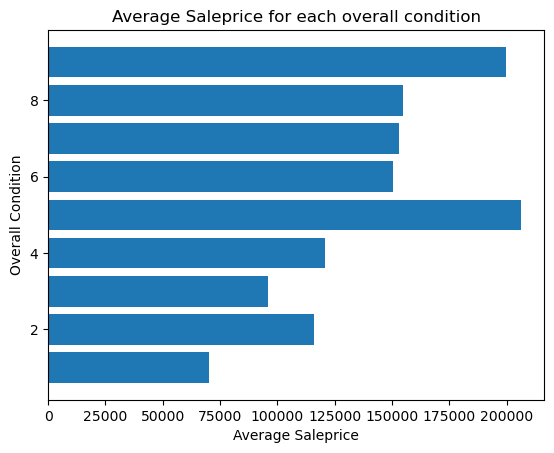

In [25]:
df_by_neighbourhood = df.groupby('Overall Cond')['SalePrice'].mean().sort_values(ascending=False).head(20).reset_index(name='SalePrice')


plt.figure()
plt.barh(df_by_neighbourhood['Overall Cond'],df_by_neighbourhood['SalePrice'])

plt.xlabel('Average Saleprice')
plt.ylabel('Overall Condition')
plt.title('Average Saleprice for each overall condition')
plt.show()

The Overall Condition value with the highest average price is 5.

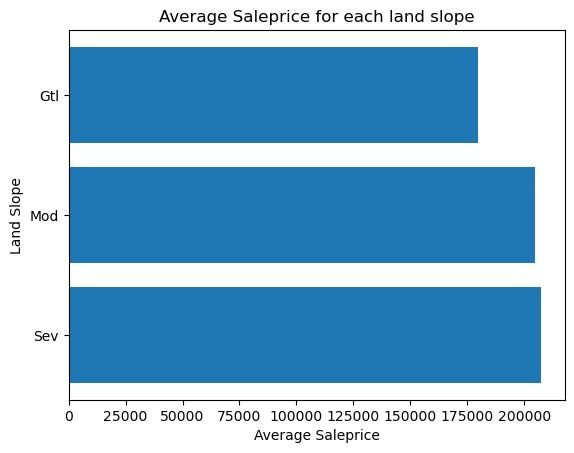

In [26]:
df_by_landslope = df.groupby('Land Slope')['SalePrice'].mean().sort_values(ascending=False).head(20).reset_index(name='SalePrice')

plt.figure()
plt.barh(df_by_landslope['Land Slope'],df_by_landslope['SalePrice'])

plt.xlabel('Average Saleprice')
plt.ylabel('Land Slope')
plt.title('Average Saleprice for each land slope')
plt.show()

The Land slope type with the highest average house price  is Sev  . This might be that this landslope type is expensive to build on.

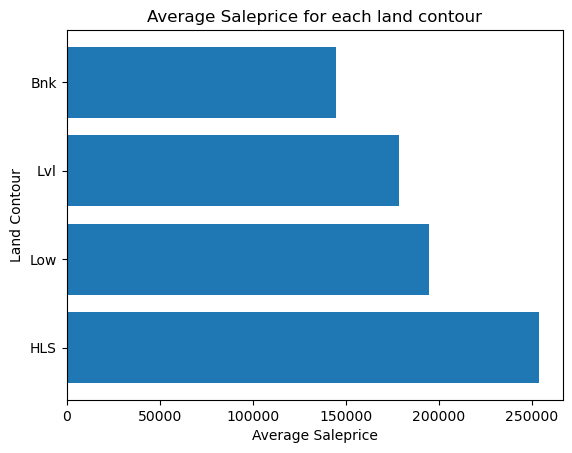

In [27]:
df_by_landcontour = df.groupby('Land Contour')['SalePrice'].mean().sort_values(ascending=False).head(20).reset_index(name='SalePrice')

plt.figure()
plt.barh(df_by_landcontour['Land Contour'],df_by_landcontour['SalePrice'])

plt.xlabel('Average Saleprice')
plt.ylabel('Land Contour')
plt.title('Average Saleprice for each land contour')
plt.show()

The Land contour with the highest average housing sale price is HLS . 

The 'SalePrice' column is skewed to the right. The log transformation was performed on the 'SalePrice' column in order to shorten the luxury end of the tail. This is so that the distribution of the target variable becomes more symmetric.

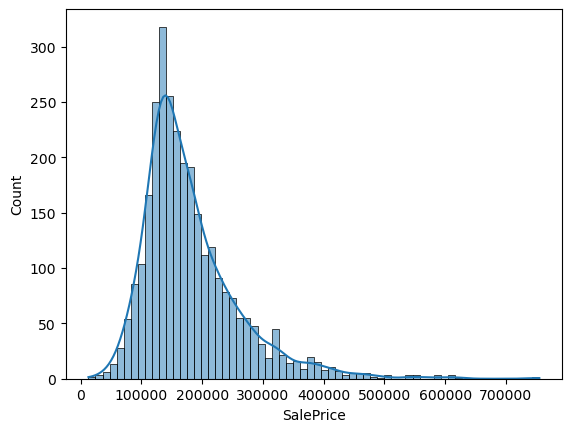

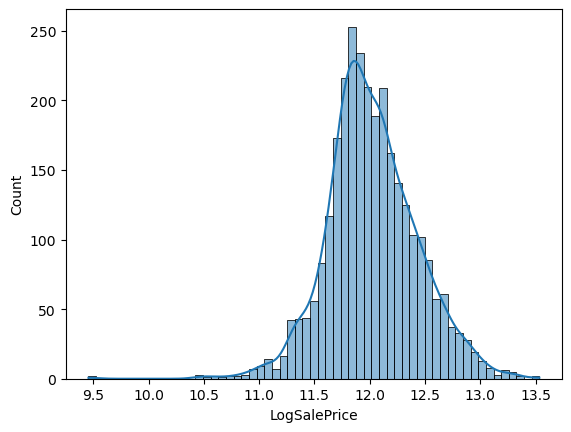

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.histplot(df['SalePrice'], kde=True)
plt.show()

df['LogSalePrice'] = np.log1p(df['SalePrice'])
sns.histplot(df['LogSalePrice'], kde=True)
plt.show()


# Pearson Correlation plot and Dimensionality reduction for linear regression model

This plot is to see which features have a strong linear correlation with the target variable. The features with strong linear correlation ,with absolute correlation value above 0.6 are selected as features for the linear regression model. This is to perform dimensionality reduction on the features for Ames.

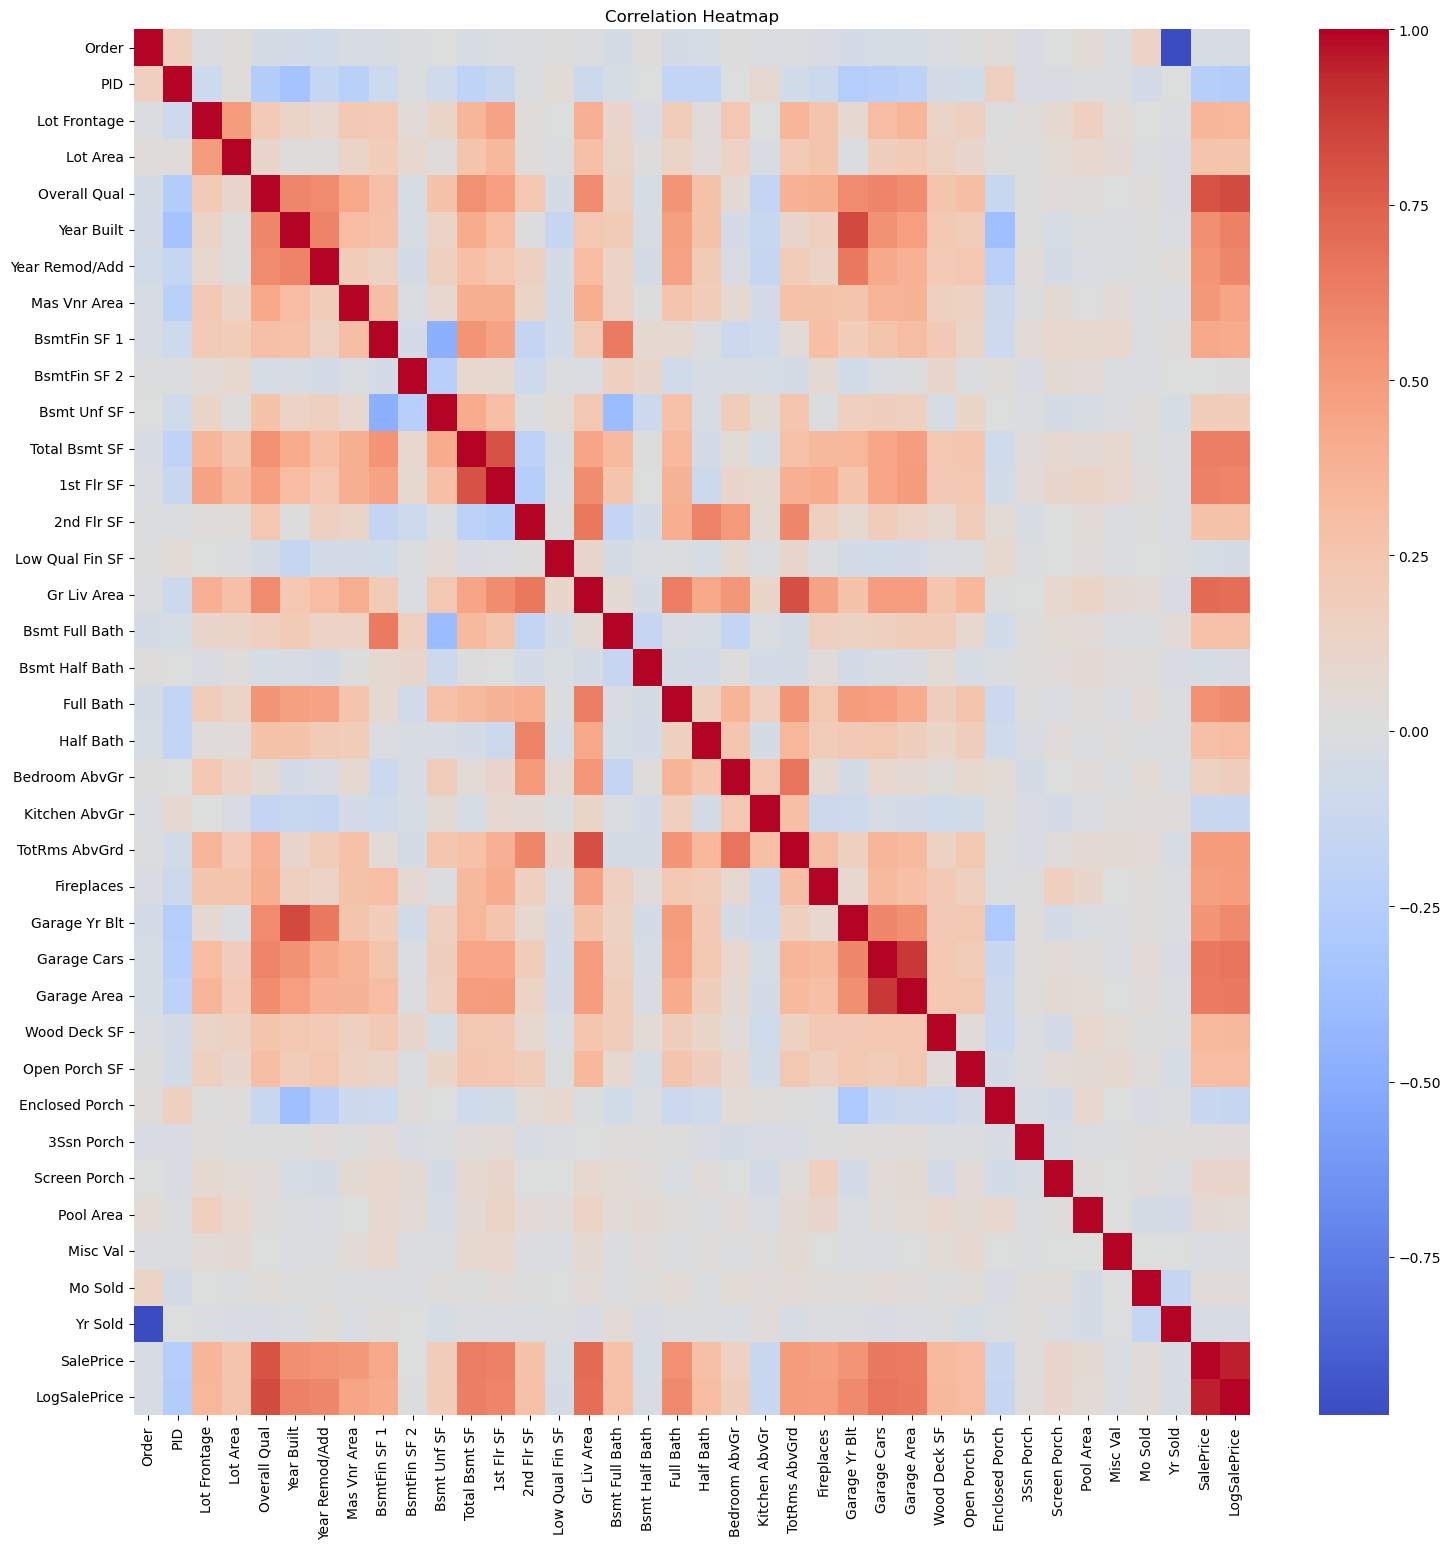

In [29]:
# Plotting the Pearson correlation heatmap.
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[num_cols].corr()
plt.figure(figsize=(18,18))

sns.heatmap(corr, annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [30]:
corr_matrix = df[num_cols].corr()  # Pearson correlation by default
saleprice_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
print(saleprice_corr)

SalePrice          1.000000
LogSalePrice       0.946304
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
Kitchen AbvGr     -0

## Searching features for the dimensionality reduction  for the linear regression model

Indentifying columns with high linear correlation and analyse any correlations between those columns to check for multicollinearity. The features that are strongly correlated with the 'SalePrice'column are selected for the linear model. The correlation coeffecient threshold for selection is absolute value of 0.6 . Then the features are checked for multicollinearity.

In [31]:
strong_corr = saleprice_corr[abs(saleprice_corr) > 0.6]
print(strong_corr)

strong_corr = strong_corr.drop(
    index=["SalePrice", "LogSalePrice"],
    columns=["SalePrice", "LogSalePrice"],
    errors="ignore"
    
    
)


print('\n',strong_corr)

SalePrice        1.000000
LogSalePrice     0.946304
Overall Qual     0.799262
Gr Liv Area      0.706780
Garage Cars      0.647877
Garage Area      0.640401
Total Bsmt SF    0.632280
1st Flr SF       0.621676
Name: SalePrice, dtype: float64

 Overall Qual     0.799262
Gr Liv Area      0.706780
Garage Cars      0.647877
Garage Area      0.640401
Total Bsmt SF    0.632280
1st Flr SF       0.621676
Name: SalePrice, dtype: float64


In [32]:
top_features = strong_corr.index[:6]



<Figure size 640x480 with 0 Axes>

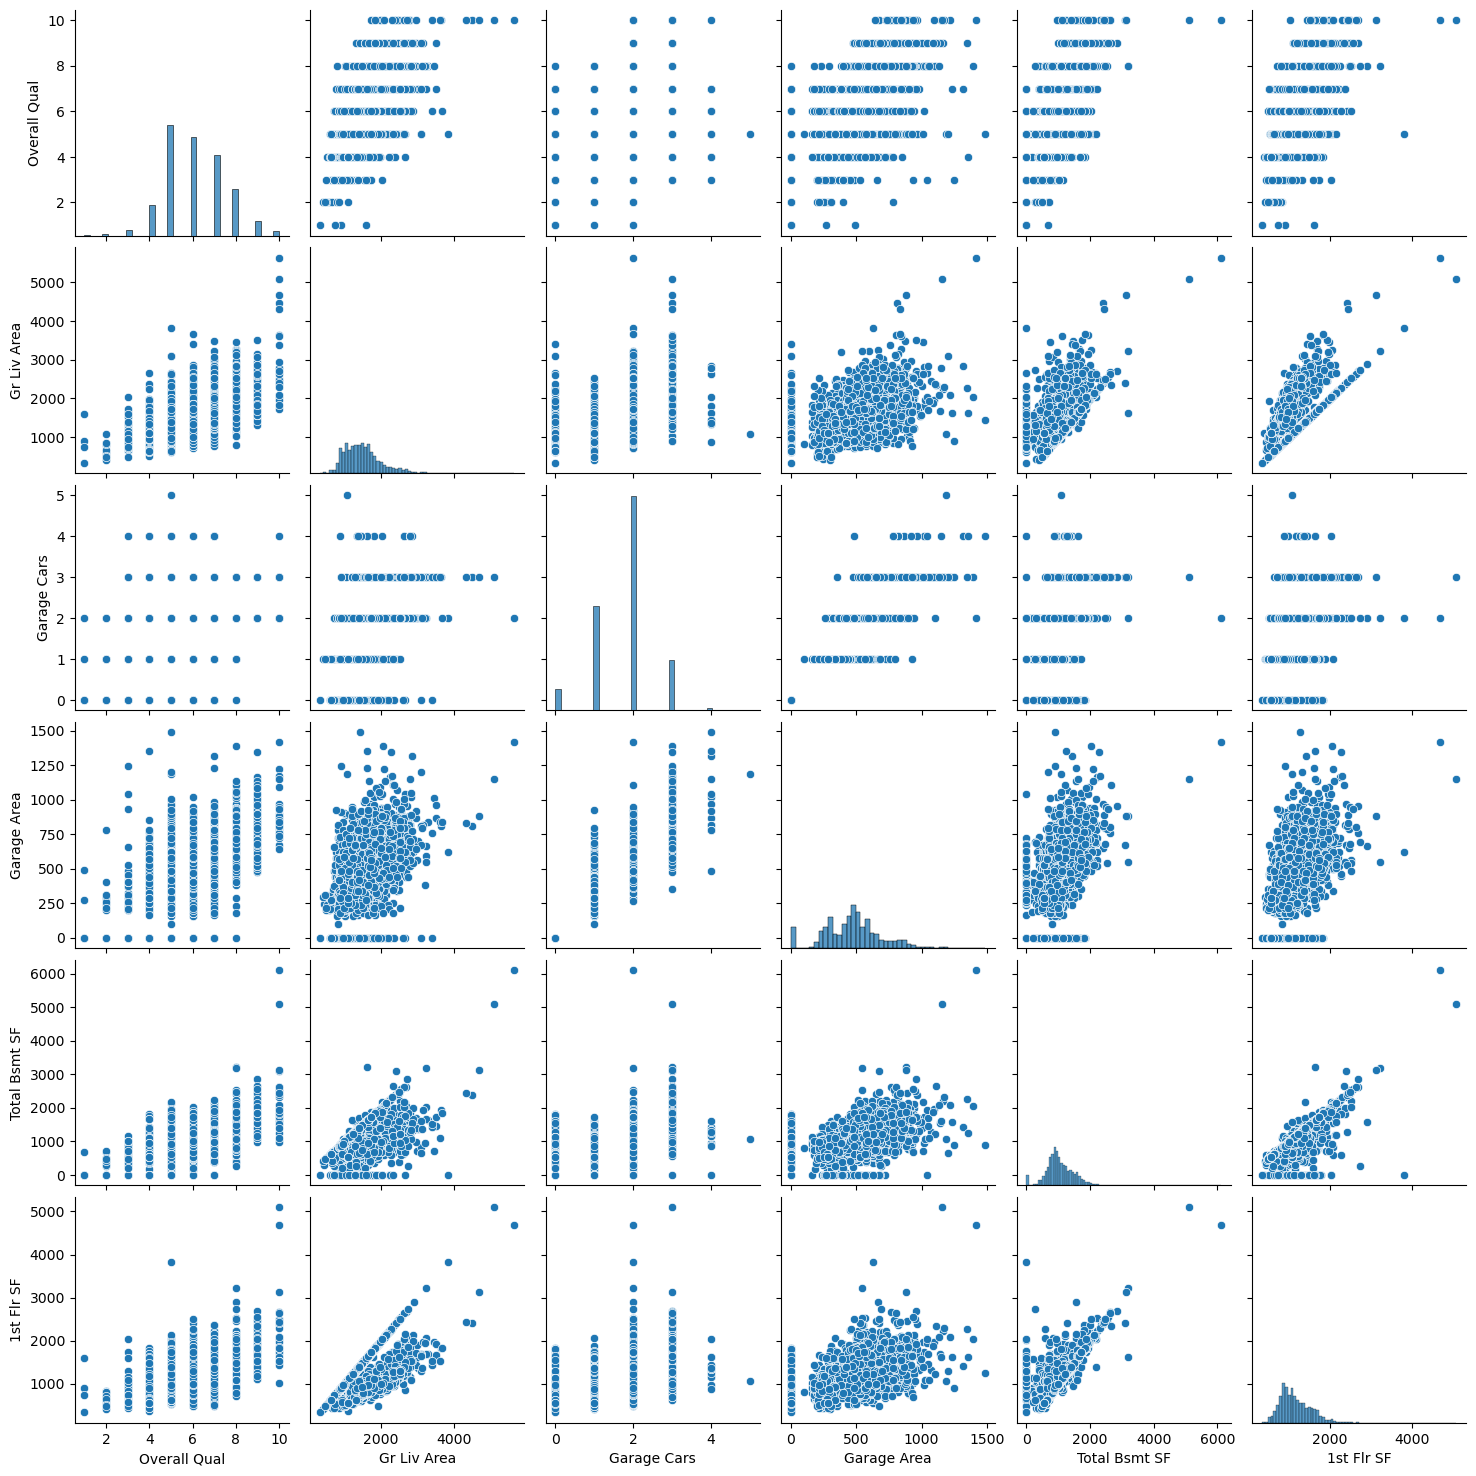

In [33]:
plt.figure()
sns.pairplot(df[top_features])
 

Distributions of the numerical features with linear strong correlation with Pearsonr correlation map

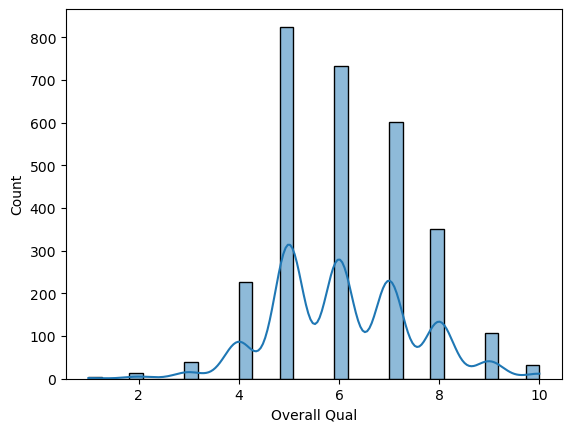

In [34]:
sns.histplot(df['Overall Qual'], kde=True)
plt.show()

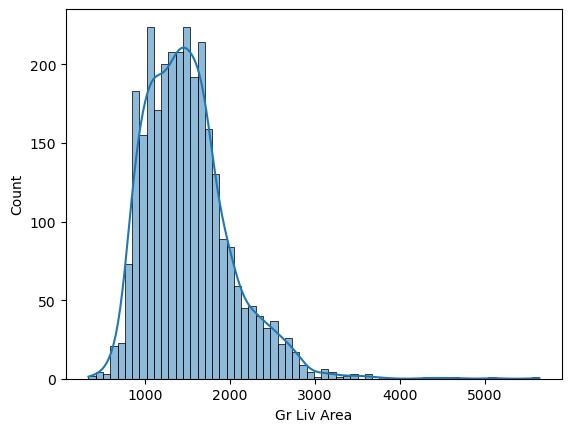

In [35]:
sns.histplot(df['Gr Liv Area'], kde=True)
plt.show()

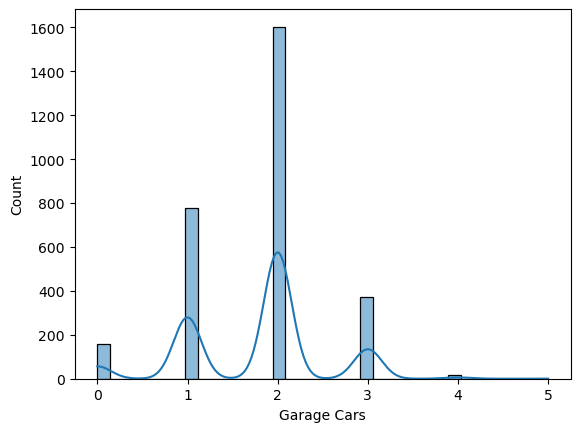

In [36]:
sns.histplot(df['Garage Cars'], kde=True)
plt.show()

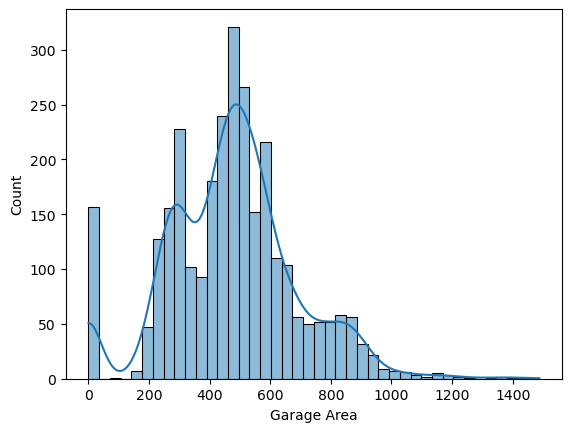

In [37]:
sns.histplot(df['Garage Area'], kde=True)
plt.show()

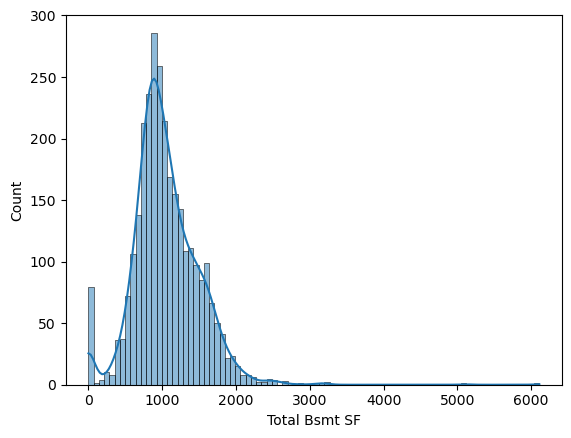

In [38]:
sns.histplot(df['Total Bsmt SF'], kde=True)
plt.show()

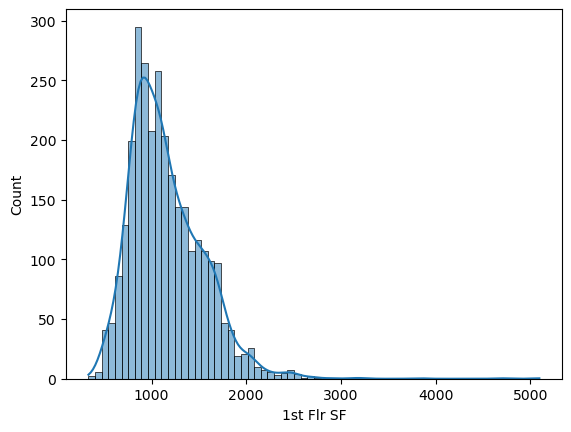

In [39]:
sns.histplot(df['1st Flr SF'], kde=True)
plt.show()

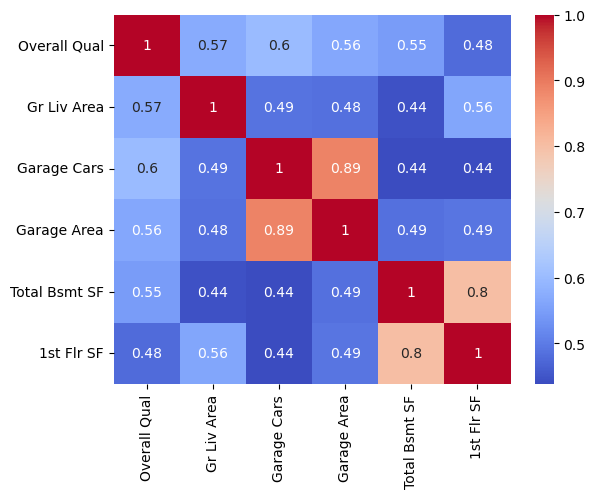

In [40]:
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.show()

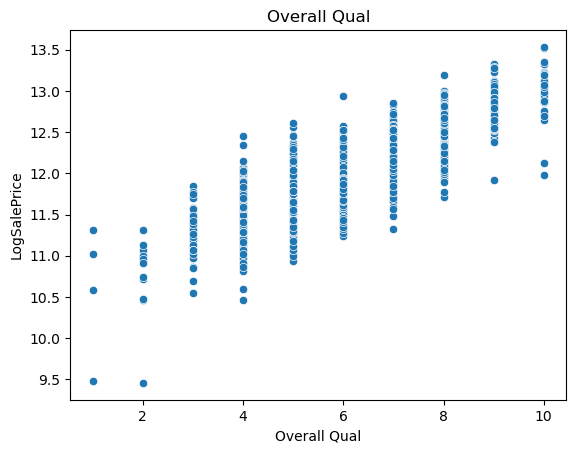

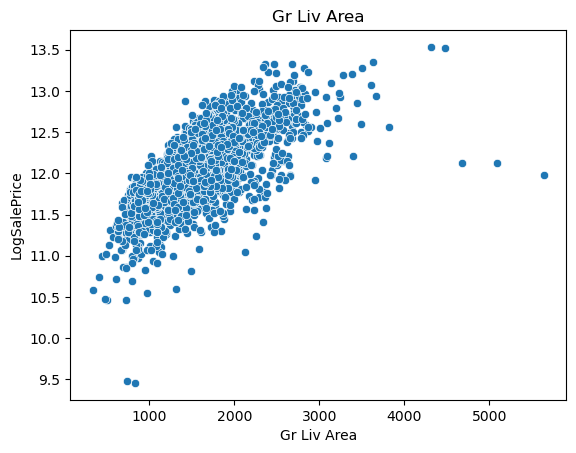

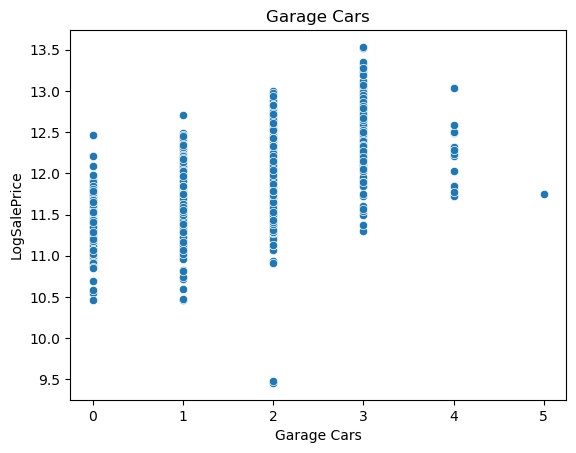

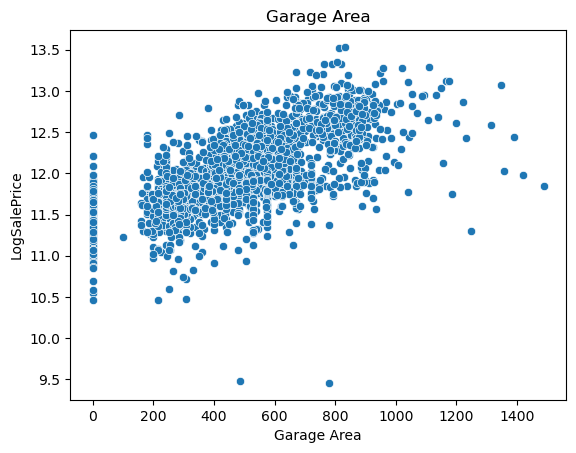

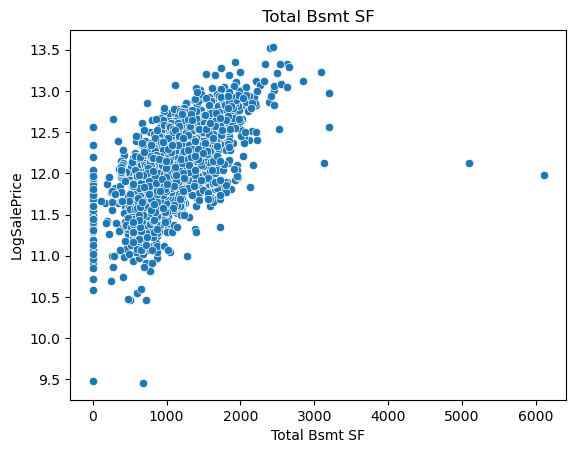

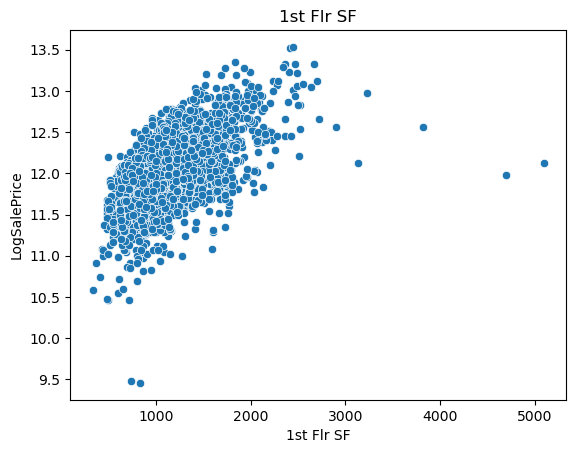

In [41]:
for col in top_features:
    sns.scatterplot(x=df[col], y=df['LogSalePrice'])
    plt.title(col)
    plt.show()

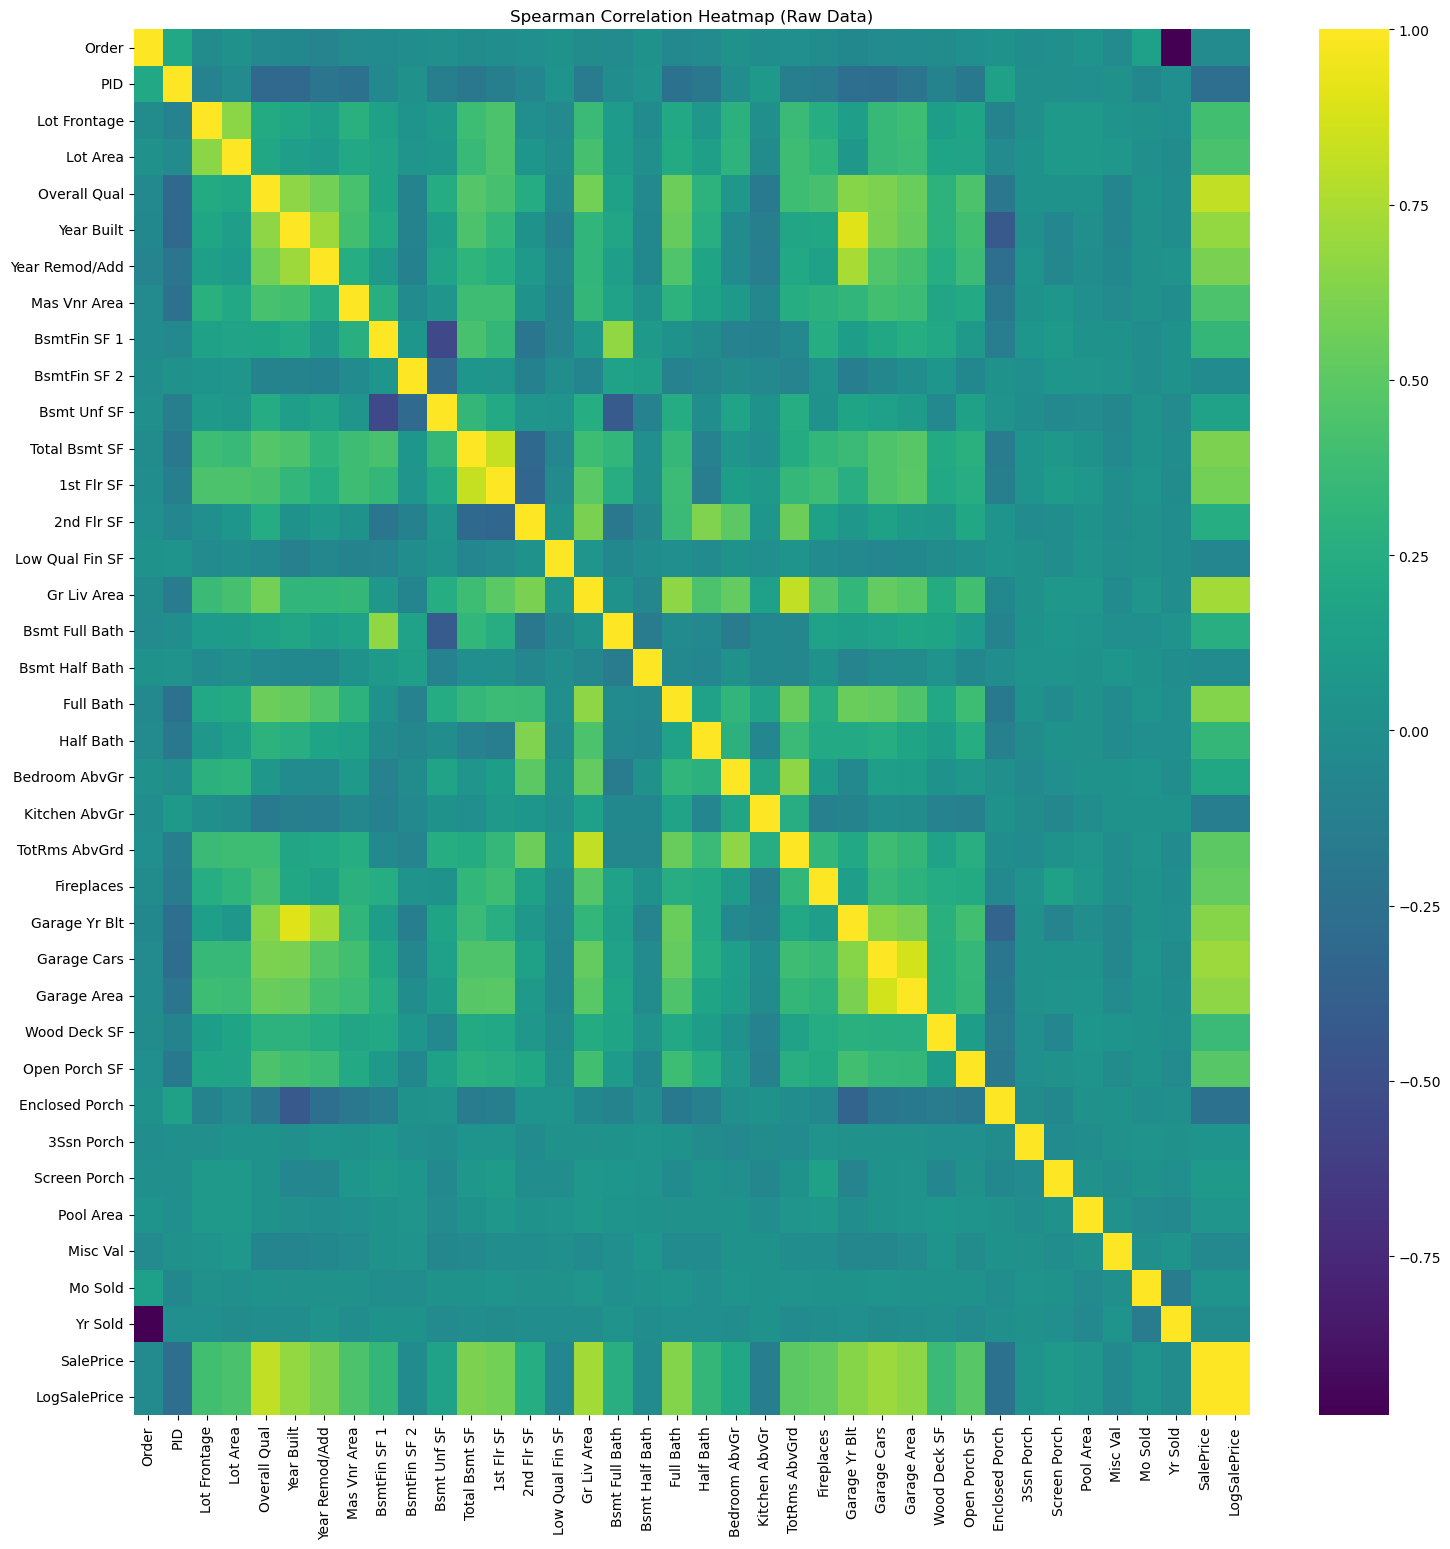

In [42]:
# Plotting the Spearman correlation heatmap.

corr_spearman = df[num_cols].corr(method='spearman')

plt.figure(figsize=(18,18))
sns.heatmap(corr_spearman, annot=False, fmt=".2f", cmap='viridis')
plt.title("Spearman Correlation Heatmap (Raw Data)")
plt.show()

In [43]:
corr_matrix = df[num_cols].corr(method='spearman')  # Spearman correlation by default
saleprice_corr_spear = corr_matrix['SalePrice'].sort_values(ascending=False)
print(saleprice_corr_spear)

LogSalePrice       1.000000
SalePrice          1.000000
Overall Qual       0.808800
Gr Liv Area        0.723342
Garage Cars        0.701813
Year Built         0.680822
Garage Area        0.660676
Garage Yr Blt      0.637674
Full Bath          0.634161
Total Bsmt SF      0.606184
Year Remod/Add     0.601454
1st Flr SF         0.581536
Fireplaces         0.526137
TotRms AbvGrd      0.499253
Open Porch SF      0.479578
Mas Vnr Area       0.442471
Lot Area           0.429249
Lot Frontage       0.397980
Wood Deck SF       0.364185
Half Bath          0.333657
BsmtFin SF 1       0.332123
Bsmt Full Bath     0.259522
2nd Flr SF         0.246861
Bedroom AbvGr      0.196834
Bsmt Unf SF        0.163361
Screen Porch       0.092909
Pool Area          0.053570
Mo Sold            0.047163
3Ssn Porch         0.043784
Yr Sold           -0.021535
Bsmt Half Bath    -0.029554
BsmtFin SF 2      -0.034092
Order             -0.035703
Misc Val          -0.049764
Low Qual Fin SF   -0.071947
Kitchen AbvGr     -0

In [44]:
strong_corr_spear = saleprice_corr_spear[abs(saleprice_corr_spear) > 0.6]
print(strong_corr_spear)

LogSalePrice      1.000000
SalePrice         1.000000
Overall Qual      0.808800
Gr Liv Area       0.723342
Garage Cars       0.701813
Year Built        0.680822
Garage Area       0.660676
Garage Yr Blt     0.637674
Full Bath         0.634161
Total Bsmt SF     0.606184
Year Remod/Add    0.601454
Name: SalePrice, dtype: float64


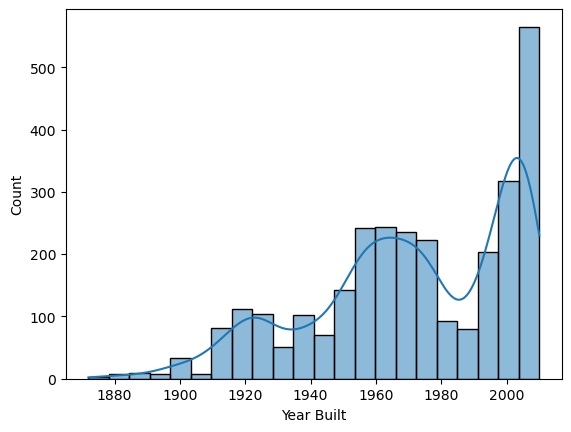

In [45]:
sns.histplot(df['Year Built'], kde=True)
plt.show()

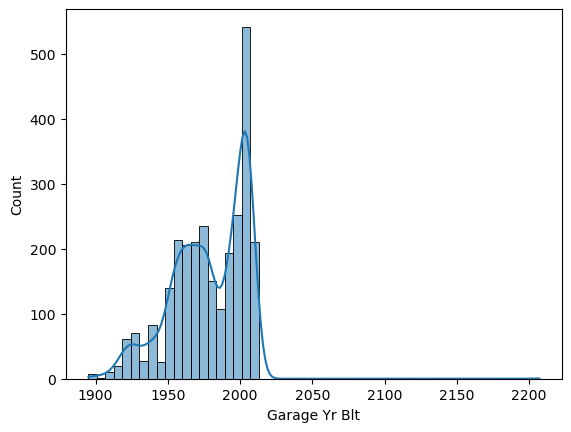

In [46]:
sns.histplot(df['Garage Yr Blt'], kde=True)
plt.show()

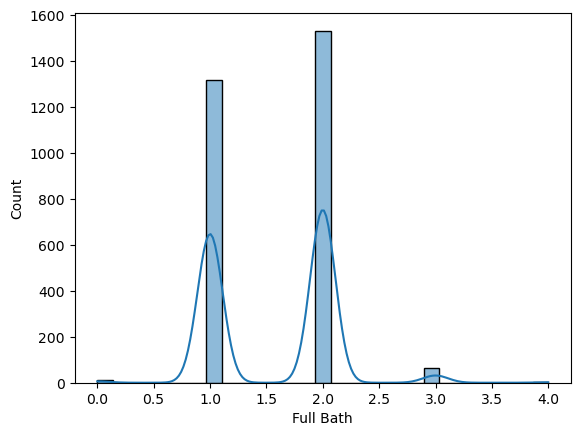

In [47]:
sns.histplot(df['Full Bath'], kde=True)
plt.show()

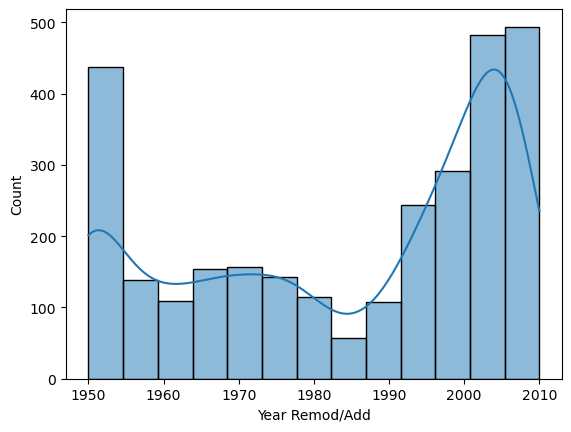

In [48]:
sns.histplot(df['Year Remod/Add'], kde=True)
plt.show()

In [49]:
strong_corr_spear = strong_corr_spear.drop(
    index=["SalePrice", "LogSalePrice"],
    columns=["SalePrice", "LogSalePrice"],
    errors="ignore"
    
    
)


print('\n',strong_corr_spear)


 Overall Qual      0.808800
Gr Liv Area       0.723342
Garage Cars       0.701813
Year Built        0.680822
Garage Area       0.660676
Garage Yr Blt     0.637674
Full Bath         0.634161
Total Bsmt SF     0.606184
Year Remod/Add    0.601454
Name: SalePrice, dtype: float64


Scatter plot between the 'LogSaleprice' and the top features . This is to have a clearer understanding of the relationship between the logSalePrice and the features.

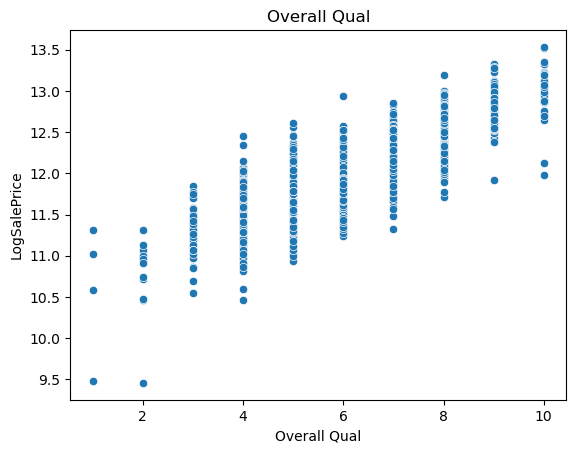

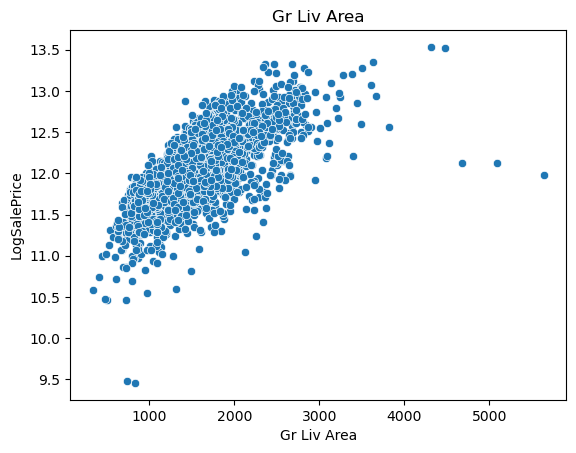

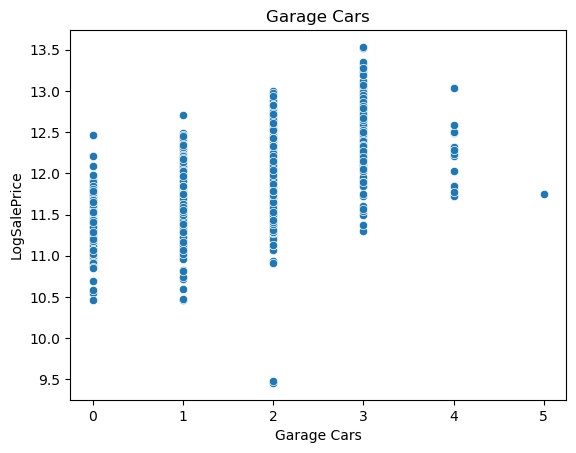

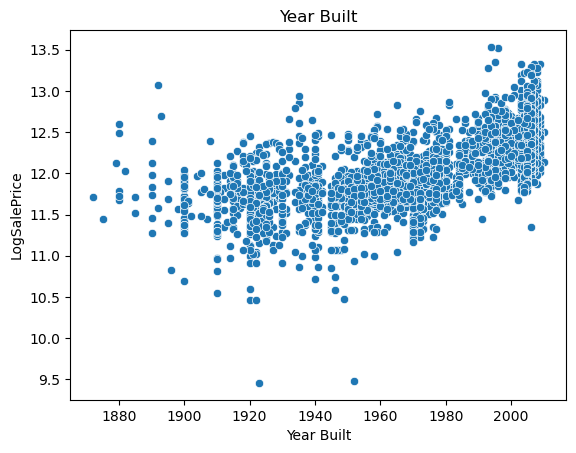

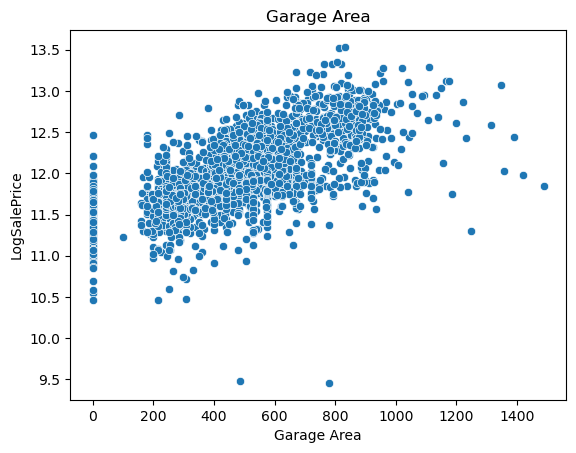

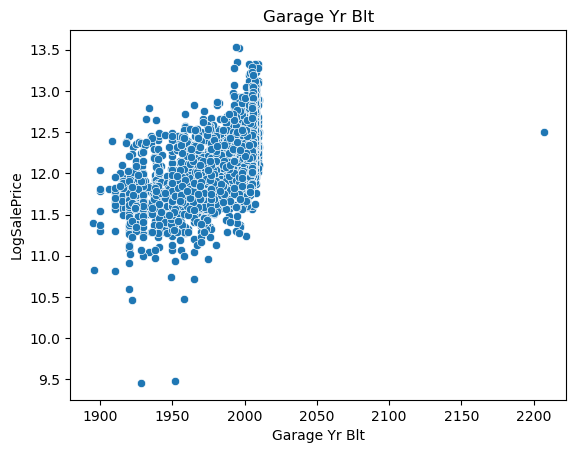

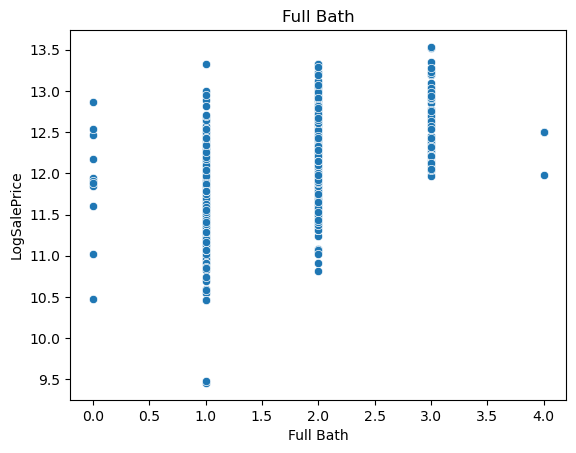

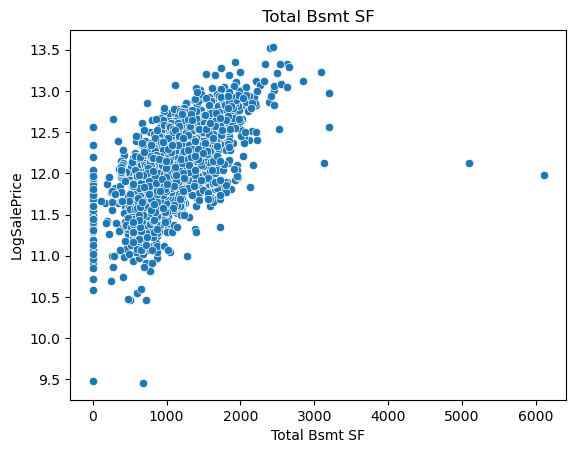

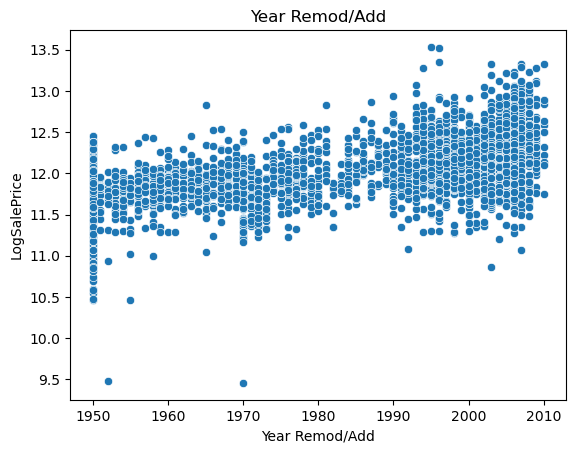

In [50]:
top_features_spear = strong_corr_spear.index[:9]

for col in top_features_spear:
    sns.scatterplot(x=df[col], y=df['LogSalePrice'])
    plt.title(col)
    plt.show()

The saleprice average calculated in the cell below will  be  used as reference for outlier analysis

In [51]:
# The average of the saleprice
print('The average SalePrice is : $' ,df['SalePrice'].mean())
print('The average log Sale Price is : $',df['LogSalePrice'].mean())

The average SalePrice is : $ 180796.0600682594
The average log Sale Price is : $ 12.020975245392643


## Missing value Handling

In [52]:
for col in object_cols:
      # mode() returns a Series; take the first mode
    df[col].fillna('None', inplace=True)

C:\Users\sibus\AppData\Local\Temp\ipykernel_21500\1436329935.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('None', inplace=True)


Mean imputation:
1.Reduces variance
2. Can bias correlations

Median is often safer for skewed variables (many Ames features are right-skewed)

For skewed numerical features, median imputation may be more robust than mean

In [53]:
for col in non_object_cols:
    mean_val = df[col].median()
    df[col].fillna(mean_val,inplace=True)

C:\Users\sibus\AppData\Local\Temp\ipykernel_21500\3399527043.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_val,inplace=True)


In [54]:
df.isnull().sum()  # Checking if missing values have been eradicated

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
LogSalePrice      0
Length: 79, dtype: int64

I plotted the Pearson and Spearman correlation heatmap  before outlier investigation
columns that have strong correlation with the target variable. The importance is due to data type being continuous and the correlation 
between column and sale price being closer to 1. This was done to see if outlires have an impact on the correlation of 
the different with the sale price column. It was also done to see variables that are linearly and non-linearly  correlated
to the sale price column.

Boxplots were plotted  to detect outliers. Then the outliers were detected using the IQR method

## Outlier Detection and Five number summary

The outliers were detected by using the IQR method. Then the data for the outliers were presented to investigate the outliers. A five number analysis was performed on the data.

In [55]:
def outlier_df(df, feature):
    return df[[feature, 'SalePrice', 'LogSalePrice']].dropna()

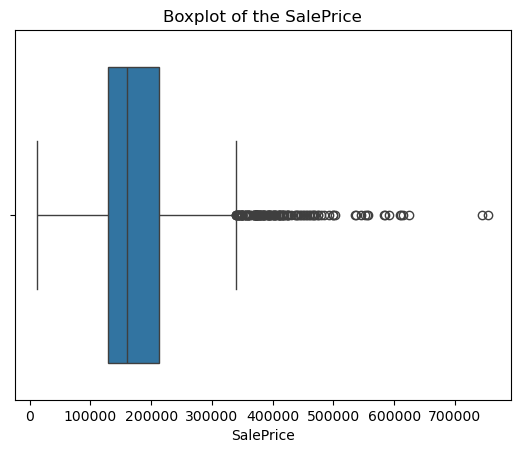

In [56]:
# Detecting outlier

sns.boxplot(x=df['SalePrice'])
plt.title('Boxplot of the SalePrice')
plt.show()

In [57]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR




df_outlier_saleP = df[(df['SalePrice'] <= lower_bound) | (df['SalePrice'] >= upper_bound)]

df_outlier_saleP[['Gr Liv Area','SalePrice','LogSalePrice']]


,Gr Liv Area,SalePrice,LogSalePrice
15,3279,538000,13.195616
17,1856,394432,12.885205
36,2334,376162,12.837778
38,1940,395192,12.887130
44,2364,611657,13.323929
...,...,...,...
2666,3608,475000,13.071072
2737,3672,415000,12.936036
2883,1778,375000,12.834684
2901,2028,369900,12.820991


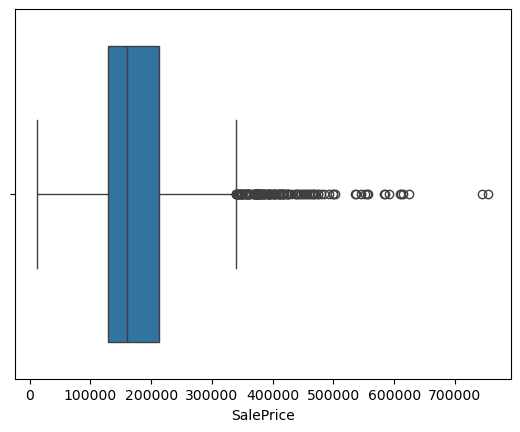

In [58]:
sns.boxplot(x=df['SalePrice'])
plt.show()

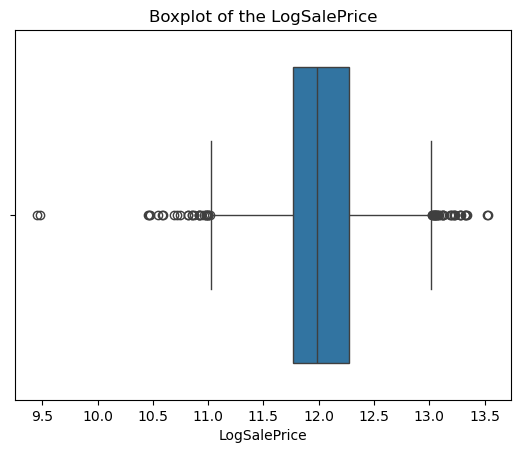

In [59]:
sns.boxplot(x=df['LogSalePrice'])
plt.title('Boxplot of the LogSalePrice')
plt.show()

In [60]:
Q1 = df['LogSalePrice'].quantile(0.25)
Q3 = df['LogSalePrice'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outlier_logsaleP = df[(df['LogSalePrice'] <= lower_bound) | (df['LogSalePrice'] >= upper_bound)]
df_outlier_logsaleP[['Gr Liv Area','Lot Frontage','LogSalePrice','SalePrice']]

,Gr Liv Area,Lot Frontage,LogSalePrice,SalePrice
15,3279,47.0,13.195616,538000
44,2364,100.0,13.323929,611657
46,2696,110.0,13.122365,500000
181,832,68.0,9.456419,12789
206,1092,70.0,10.915107,55000
287,864,45.0,10.976799,58500
306,1044,66.0,10.933000,55993
307,952,66.0,10.822554,50138
366,2234,63.0,13.126033,501837
421,2772,110.0,13.043322,462000


The house with index number 181 must be an error in recording information. This because the average sale price is \$ 180796.0600682594  and the house has value of \$ 12 789. The other houses with comparable Gr Liv Area have values around \$ 45 000. Also there are other houses with 'Lot Frontage' less than that of the house with comparable Gr Liv Area value.The same is true for 1553 

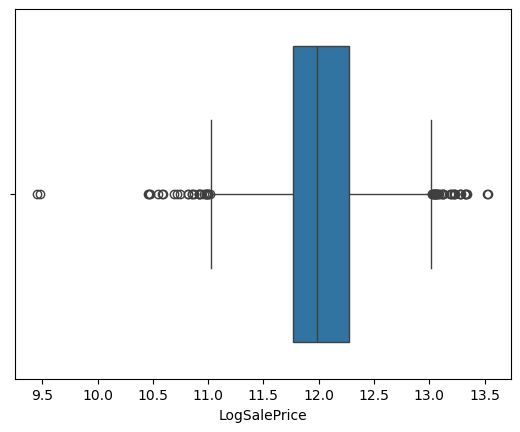

In [61]:
sns.boxplot(x=df['LogSalePrice'])
plt.show()

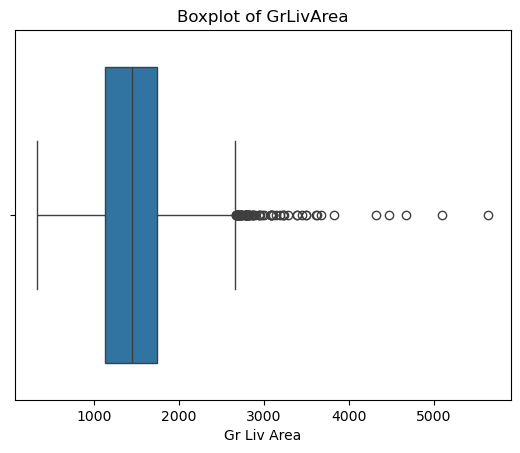

In [62]:
sns.boxplot(x=df['Gr Liv Area'])
plt.title('Boxplot of GrLivArea')
plt.show()

In [63]:
# Calculate IQR
Q1 = df['Gr Liv Area'].quantile(0.25)
Q3 = df['Gr Liv Area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_outlier_GrLivArea = df[(df['Gr Liv Area'] <= lower_bound) | (df['Gr Liv Area'] >= upper_bound)]

df_outlier_GrLivArea[['Gr Liv Area','SalePrice','LogSalePrice']]

,Gr Liv Area,SalePrice,LogSalePrice
15,3279,538000,13.195616
46,2696,500000,13.122365
65,3238,410000,12.923915
160,2978,242000,12.396697
253,3222,320000,12.676079
...,...,...,...
2453,2799,315000,12.660331
2500,2826,334000,12.718899
2570,3112,235000,12.367345
2666,3608,475000,13.071072


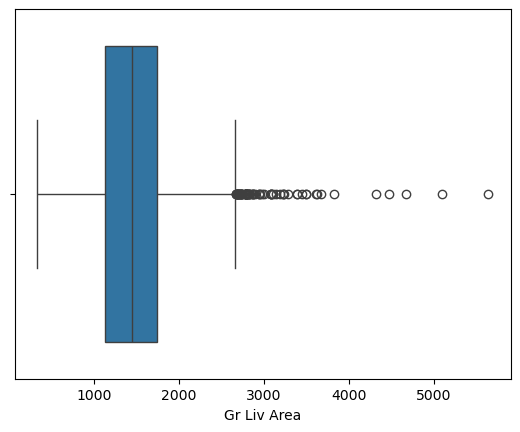

In [64]:
sns.boxplot(x=df['Gr Liv Area'])
plt.show()

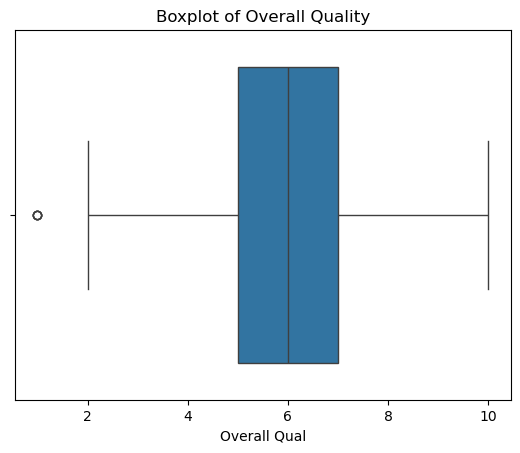

In [65]:
sns.boxplot(x=df['Overall Qual'])
plt.title('Boxplot of Overall Quality')
plt.show()

In [66]:
# Calculate IQR
Q1 = df['Overall Qual'].quantile(0.25)
Q3 = df['Overall Qual'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_outlier_OverallQ = df[(df['Overall Qual'] <= lower_bound) | (df['Overall Qual'] >= upper_bound)]

df_outlier_GrLivArea[['Overall Qual','SalePrice','LogSalePrice']]

,Overall Qual,SalePrice,LogSalePrice
15,8,538000,13.195616
46,9,500000,13.122365
65,8,410000,12.923915
160,7,242000,12.396697
253,7,320000,12.676079
...,...,...,...
2453,8,315000,12.660331
2500,8,334000,12.718899
2570,8,235000,12.367345
2666,10,475000,13.071072


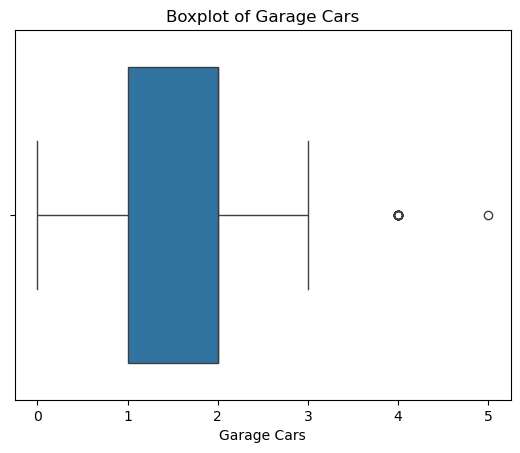

In [67]:
sns.boxplot(x=df['Garage Cars'])
plt.title('Boxplot of Garage Cars')
plt.show()

In [68]:
# Calculate IQR
Q1 = df['Garage Cars'].quantile(0.25)
Q3 = df['Garage Cars'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_outlier_GarageCars = df[(df['Garage Cars'] <= lower_bound) | (df['Garage Cars'] >= upper_bound)]
df_outlier_GarageCars[['Garage Cars','SalePrice','LogSalePrice']]

,Garage Cars,SalePrice,LogSalePrice
246,4.0,218000,12.292255
669,4.0,200000,12.206078
716,4.0,265979,12.491176
746,5.0,126500,11.748005
815,4.0,269500,12.504327
816,4.0,269500,12.504327
817,4.0,269500,12.504327
1027,4.0,292500,12.586223
1059,4.0,460000,13.038984
1258,4.0,139000,11.842236


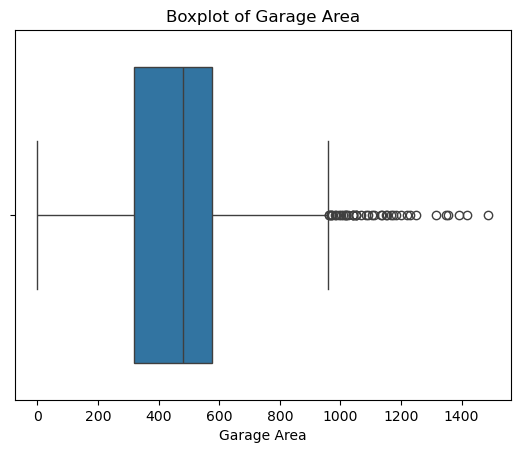

In [69]:
sns.boxplot(x=df['Garage Area'])
plt.title('Boxplot of Garage Area')
plt.show()

In [70]:
# Calculate IQR
Q1 = df['Garage Area'].quantile(0.25)
Q3 = df['Garage Area'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_outlier_GarageArea = df[(df['Garage Area'] <= lower_bound) | (df['Garage Area'] >= upper_bound)]
outlier_df(df_outlier_GarageArea,'Garage Area')

,Garage Area,SalePrice,LogSalePrice
60,962.0,355000,12.779876
246,1017.0,218000,12.292255
366,1166.0,501837,13.126033
426,1390.0,253293,12.442306
433,1020.0,582933,13.275829
447,968.0,386250,12.864243
497,1069.0,340000,12.736704
507,972.0,275000,12.524530
520,984.0,250000,12.429220
525,1043.0,252000,12.437188


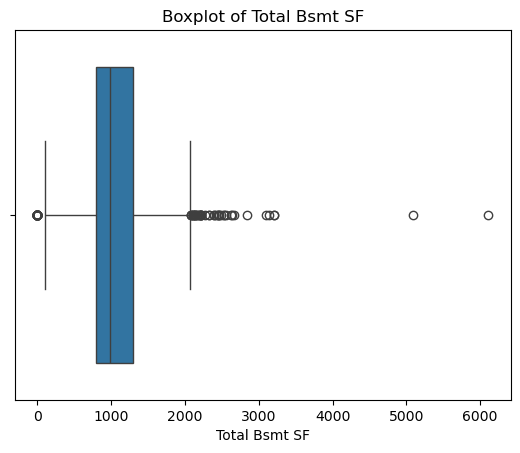

In [71]:
sns.boxplot(x=df['Total Bsmt SF'])
plt.title('Boxplot of Total Bsmt SF')
plt.show()

In [72]:
# Calculate IQR
Q1 = df['Total Bsmt SF'].quantile(0.25)
Q3 = df['Total Bsmt SF'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_TotalBSF = df[(df['Total Bsmt SF'] <= lower_bound) | (df['Total Bsmt SF'] >= upper_bound)]

outlier_df(df_TotalBSF,'Total Bsmt SF')

,Total Bsmt SF,SalePrice,LogSalePrice
3,2110.0,244000,12.404928
44,2330.0,611657,13.323929
46,2846.0,500000,13.122365
83,0.0,112000,11.626263
154,0.0,107500,11.585255
...,...,...,...
2739,0.0,135000,11.813037
2744,0.0,93000,11.440366
2879,0.0,51689,10.853020
2892,0.0,230000,12.345839


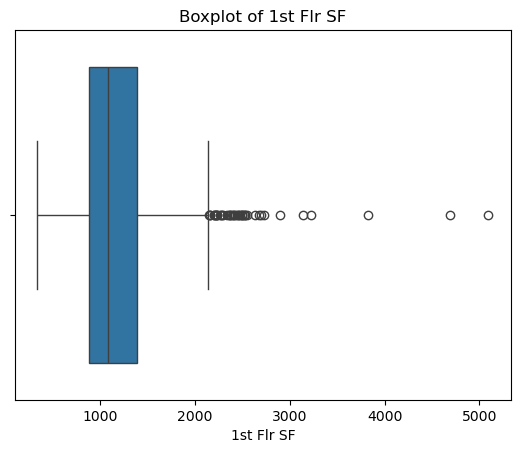

In [73]:
sns.boxplot(x=df['1st Flr SF'])
plt.title('Boxplot of 1st Flr SF')
plt.show()

In [74]:
# Calculate IQR
Q1 = df['1st Flr SF'].quantile(0.25)
Q3 = df['1st Flr SF'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_1FSF =df[(df['1st Flr SF'] <= lower_bound) | (df['1st Flr SF'] >= upper_bound)]

outlier_df(df_1FSF,'1st Flr SF')


,1st Flr SF,SalePrice,LogSalePrice
44,2364,611657,13.323929
46,2696,500000,13.122365
136,2207,180000,12.100718
349,2522,375000,12.834684
366,2234,501837,13.126033
379,2524,278000,12.535380
423,2402,555000,13.226725
432,2674,610000,13.321216
447,2392,386250,12.864243
448,2452,445000,13.005832


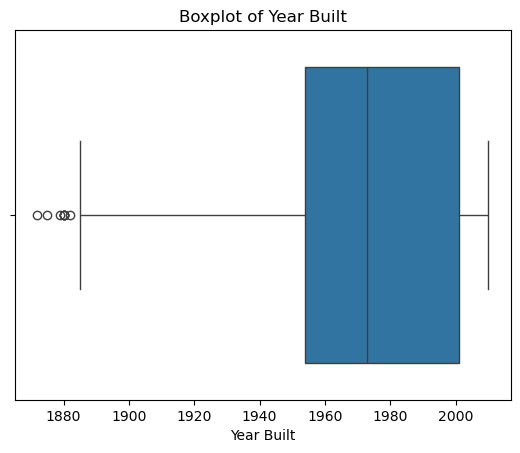

In [75]:
sns.boxplot(x=df['Year Built'])
plt.title('Boxplot of Year Built')
plt.show()

In [76]:
# Calculate IQR
Q1 = df['Year Built'].quantile(0.25)
Q3 = df['Year Built'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_YrB = df[(df['Year Built'] <= lower_bound) | (df['Year Built'] >= upper_bound)]
outlier_df(df_YrB,'Year Built')

,Year Built,SalePrice,LogSalePrice
215,1875,94000,11.451061
716,1880,265979,12.491176
719,1882,168000,12.031725
806,1880,131000,11.782960
1306,1880,295000,12.594734
1318,1872,122000,11.711785
1995,1880,117500,11.674202
1997,1879,185000,12.128117
2647,1880,124000,11.728045


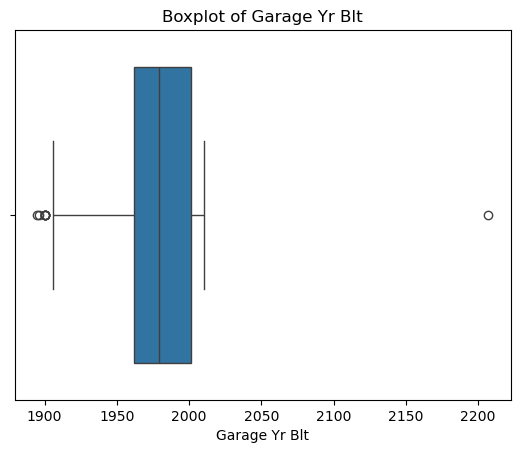

In [77]:
sns.boxplot(x=df['Garage Yr Blt'])
plt.title('Boxplot of Garage Yr Blt')
plt.show()

In [78]:
# Calculate IQR
Q1 = df['Garage Yr Blt'].quantile(0.25)
Q3 = df['Garage Yr Blt'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_GYB = df[(df['Garage Yr Blt'] <= lower_bound) | (df['Garage Yr Blt'] >= upper_bound)]
outlier_df(df_GYB,'Garage Yr Blt')

,Garage Yr Blt,SalePrice,LogSalePrice
169,1900.0,80400,11.294782
307,1896.0,50138,10.822554
806,1900.0,131000,11.782960
1554,1895.0,89000,11.396403
1610,1900.0,103000,11.542494
1998,1900.0,133900,11.804856
2260,2207.0,267300,12.496131
2599,1900.0,86900,11.372525
2635,1900.0,169000,12.037660


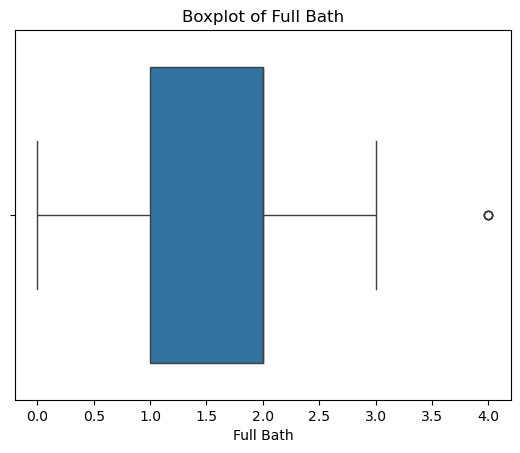

In [79]:
sns.boxplot(x=df['Full Bath'])
plt.title('Boxplot of Full Bath')
plt.show()

In [80]:
# Calculate IQR
Q1 = df['Full Bath'].quantile(0.25)
Q3 = df['Full Bath'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_FB = df[(df['Full Bath'] <= lower_bound) | (df['Full Bath'] >= upper_bound)]

outlier_df(df_FB,'Full Bath')

,Full Bath,SalePrice,LogSalePrice
336,4,159000,11.976666
815,4,269500,12.504327
816,4,269500,12.504327
817,4,269500,12.504327


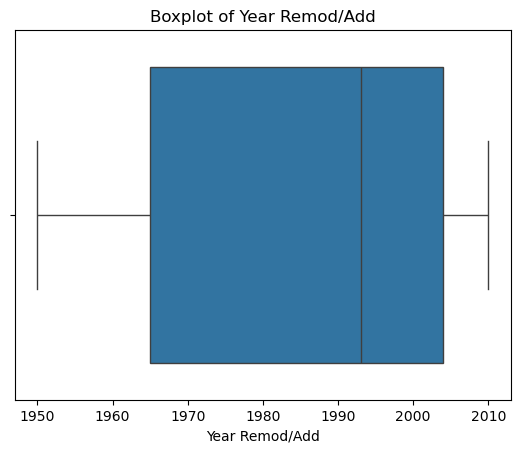

In [81]:
sns.boxplot(x=df['Year Remod/Add'])
plt.title('Boxplot of Year Remod/Add')
plt.show()

In [82]:
# Calculate IQR
Q1 = df['Year Remod/Add'].quantile(0.25)
Q3 = df['Year Remod/Add'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR



df_YRA = df[(df['Year Remod/Add'] <= lower_bound) | (df['Year Remod/Add'] >= upper_bound)]

outlier_df(df_YRA, 'Year Remod/Add') 

,Year Remod/Add,SalePrice,LogSalePrice


The outliers that have errors are investigated using the error conditions and are dropped 

In [83]:
error_conditions = (
    (df['Gr Liv Area'] > 4000) |
    (df['Garage Cars'] > 4) |
    (df['Total Bsmt SF'] > 6000) | (df['Total Bsmt SF'] < 10) |
    (df['Year Built'] > 2023) | (df['Year Built'] < 1800) |
    (df['SalePrice'] < 15000) | (df['SalePrice'] > 100000000) |
    (df['1st Flr SF'] > 4000) | (df['1st Flr SF'] < 100) |
    (df['2nd Flr SF'] > 2000) | (df['2nd Flr SF'] < 0) |
    (df['Garage Area'] > 1500) |
    (df['Year Remod/Add'] > 2023) | (df['Year Remod/Add'] < df['Year Built']) |
    (df['Full Bath'] < 0) | (df['Full Bath'] > 4)
)
inv_errors= df[error_conditions].head(20)
print(inv_errors[['Gr Liv Area','Total Bsmt SF','Year Built','Year Built','SalePrice']])  

error_rows = df[error_conditions] 

df = df.drop(error_rows.index)

#'Gr Liv Area','Garage Cars','Total Bsmt SF','Full Bath','Year Built','Year Remod/Add','SalePrice'


     Gr Liv Area  Total Bsmt SF  Year Built  Year Built  SalePrice
83          1902            0.0        1978        1978     112000
154          827            0.0        1955        1955     107500
181          832          678.0        1923        1923      12789
206         1092            0.0        1930        1930      55000
243          930            0.0        1946        1946      84900
273          640            0.0        1945        1945      84900
275         1664            0.0        1965        1965     100000
290         2650            0.0        1967        1967     160000
551         1882            0.0        1981        1981     160000
649         1210            0.0        1953        1953     102900
676         1040            0.0        1950        1950      92900
678         1040            0.0        1949        1949      90000
708          612            0.0        1940        1940      45000
746         1072         1072.0        1925        1925     12

In [84]:
df.columns   # columns in df


Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

### Heat maps after outlier removal

This was done to understand the effect of outlier removal on correlations

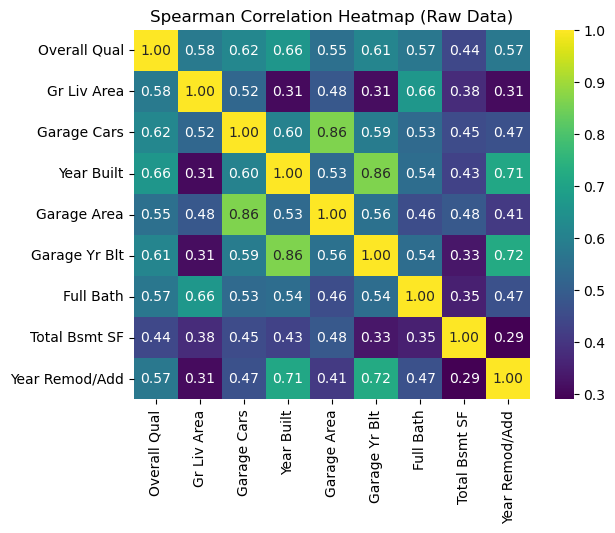

In [85]:
# Plotting the Spearman correlation heatmap.
corr_spearman = df[top_features_spear].corr(method='spearman')

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='viridis')
plt.title("Spearman Correlation Heatmap (Raw Data)")
plt.show()

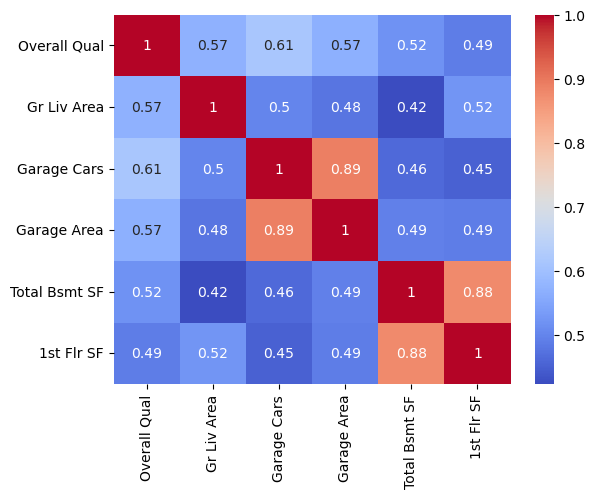

In [86]:
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.show()

<Figure size 640x480 with 0 Axes>

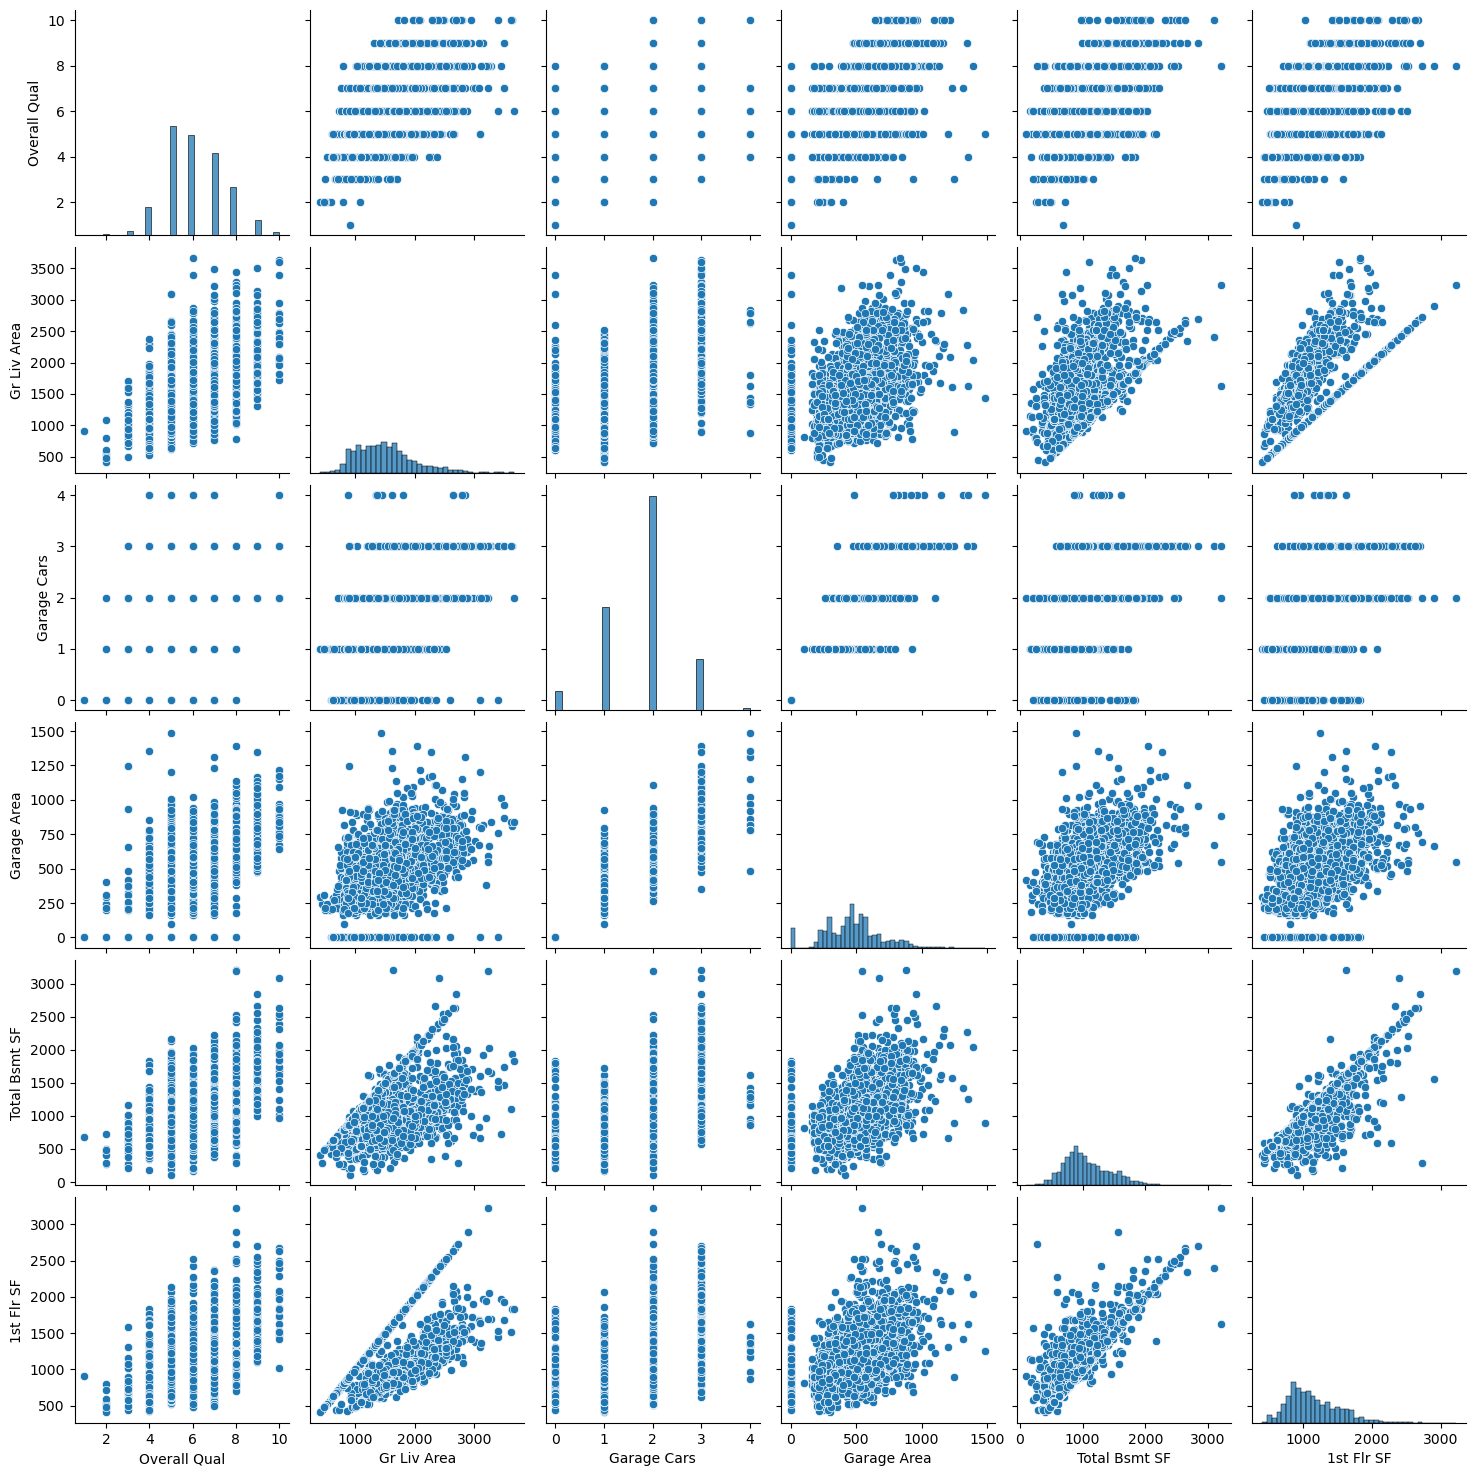

In [87]:
plt.figure()
sns.pairplot(df[top_features])

# Feature Engineering

Feature engineering was performed on the dataset in an attempt to improve results. Then the correlation heatmap plot of the numerical features after feature engineering is plotted to see the effect of feature engineering on correlations. Then the features with strong correlations were selected after the feature engineering and multicollinearity control was performed.

In [88]:
skewed_feats = ['Gr Liv Area', 'Total Bsmt SF', '1st Flr SF', 'Lot Area', 'Garage Area']
for col in skewed_feats:
    df[col] = np.log1p(df[col])

In [89]:
df['HouseAge'] = df['Yr Sold'] - df['Year Built']
df['RemodAge'] = df['Yr Sold'] - df['Year Remod/Add']

In [90]:
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
df['TotalBath'] = df['Full Bath'] + 0.5*df['Half Bath'] + \
                          df['Bsmt Full Bath'] + 0.5*df['Bsmt Half Bath']
df['TotalBath'] = df['Full Bath'] + 0.5*df['Half Bath'] + \
                          df['Bsmt Full Bath'] + 0.5*df['Bsmt Half Bath']


In [91]:
df['GarageQual_Size'] = df['Garage Cars'] * df['Garage Area']
df['Qual_SF'] = df['Overall Qual'] * df['TotalSF']


num_cols_feature_eng = df.select_dtypes(include=['float64','int64']).columns.tolist()

df.columns


Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

In [92]:
corr_matrix = df[num_cols_feature_eng].corr()
top_features_eng = corr_matrix['SalePrice'].abs().sort_values(ascending=False)

top_features_eng

SalePrice          1.000000
LogSalePrice       0.955882
Overall Qual       0.803204
Gr Liv Area        0.701562
GarageQual_Size    0.681590
Garage Cars        0.660783
TotalBath          0.633355
1st Flr SF         0.621050
Total Bsmt SF      0.596673
HouseAge           0.561473
Year Built         0.561155
Full Bath          0.552701
RemodAge           0.535658
Year Remod/Add     0.534116
Garage Yr Blt      0.512933
TotRms AbvGrd      0.507588
Mas Vnr Area       0.505058
Fireplaces         0.469812
BsmtFin SF 1       0.430920
Lot Area           0.378613
Garage Area        0.373779
Qual_SF            0.357107
Lot Frontage       0.354367
Wood Deck SF       0.319474
Open Porch SF      0.314694
Half Bath          0.276054
Bsmt Full Bath     0.266356
TotalSF            0.250962
2nd Flr SF         0.249868
PID                0.243464
Bsmt Unf SF        0.159131
Enclosed Porch     0.132355
Bedroom AbvGr      0.132220
Screen Porch       0.115524
Kitchen AbvGr      0.093861
Bsmt Half Bath     0

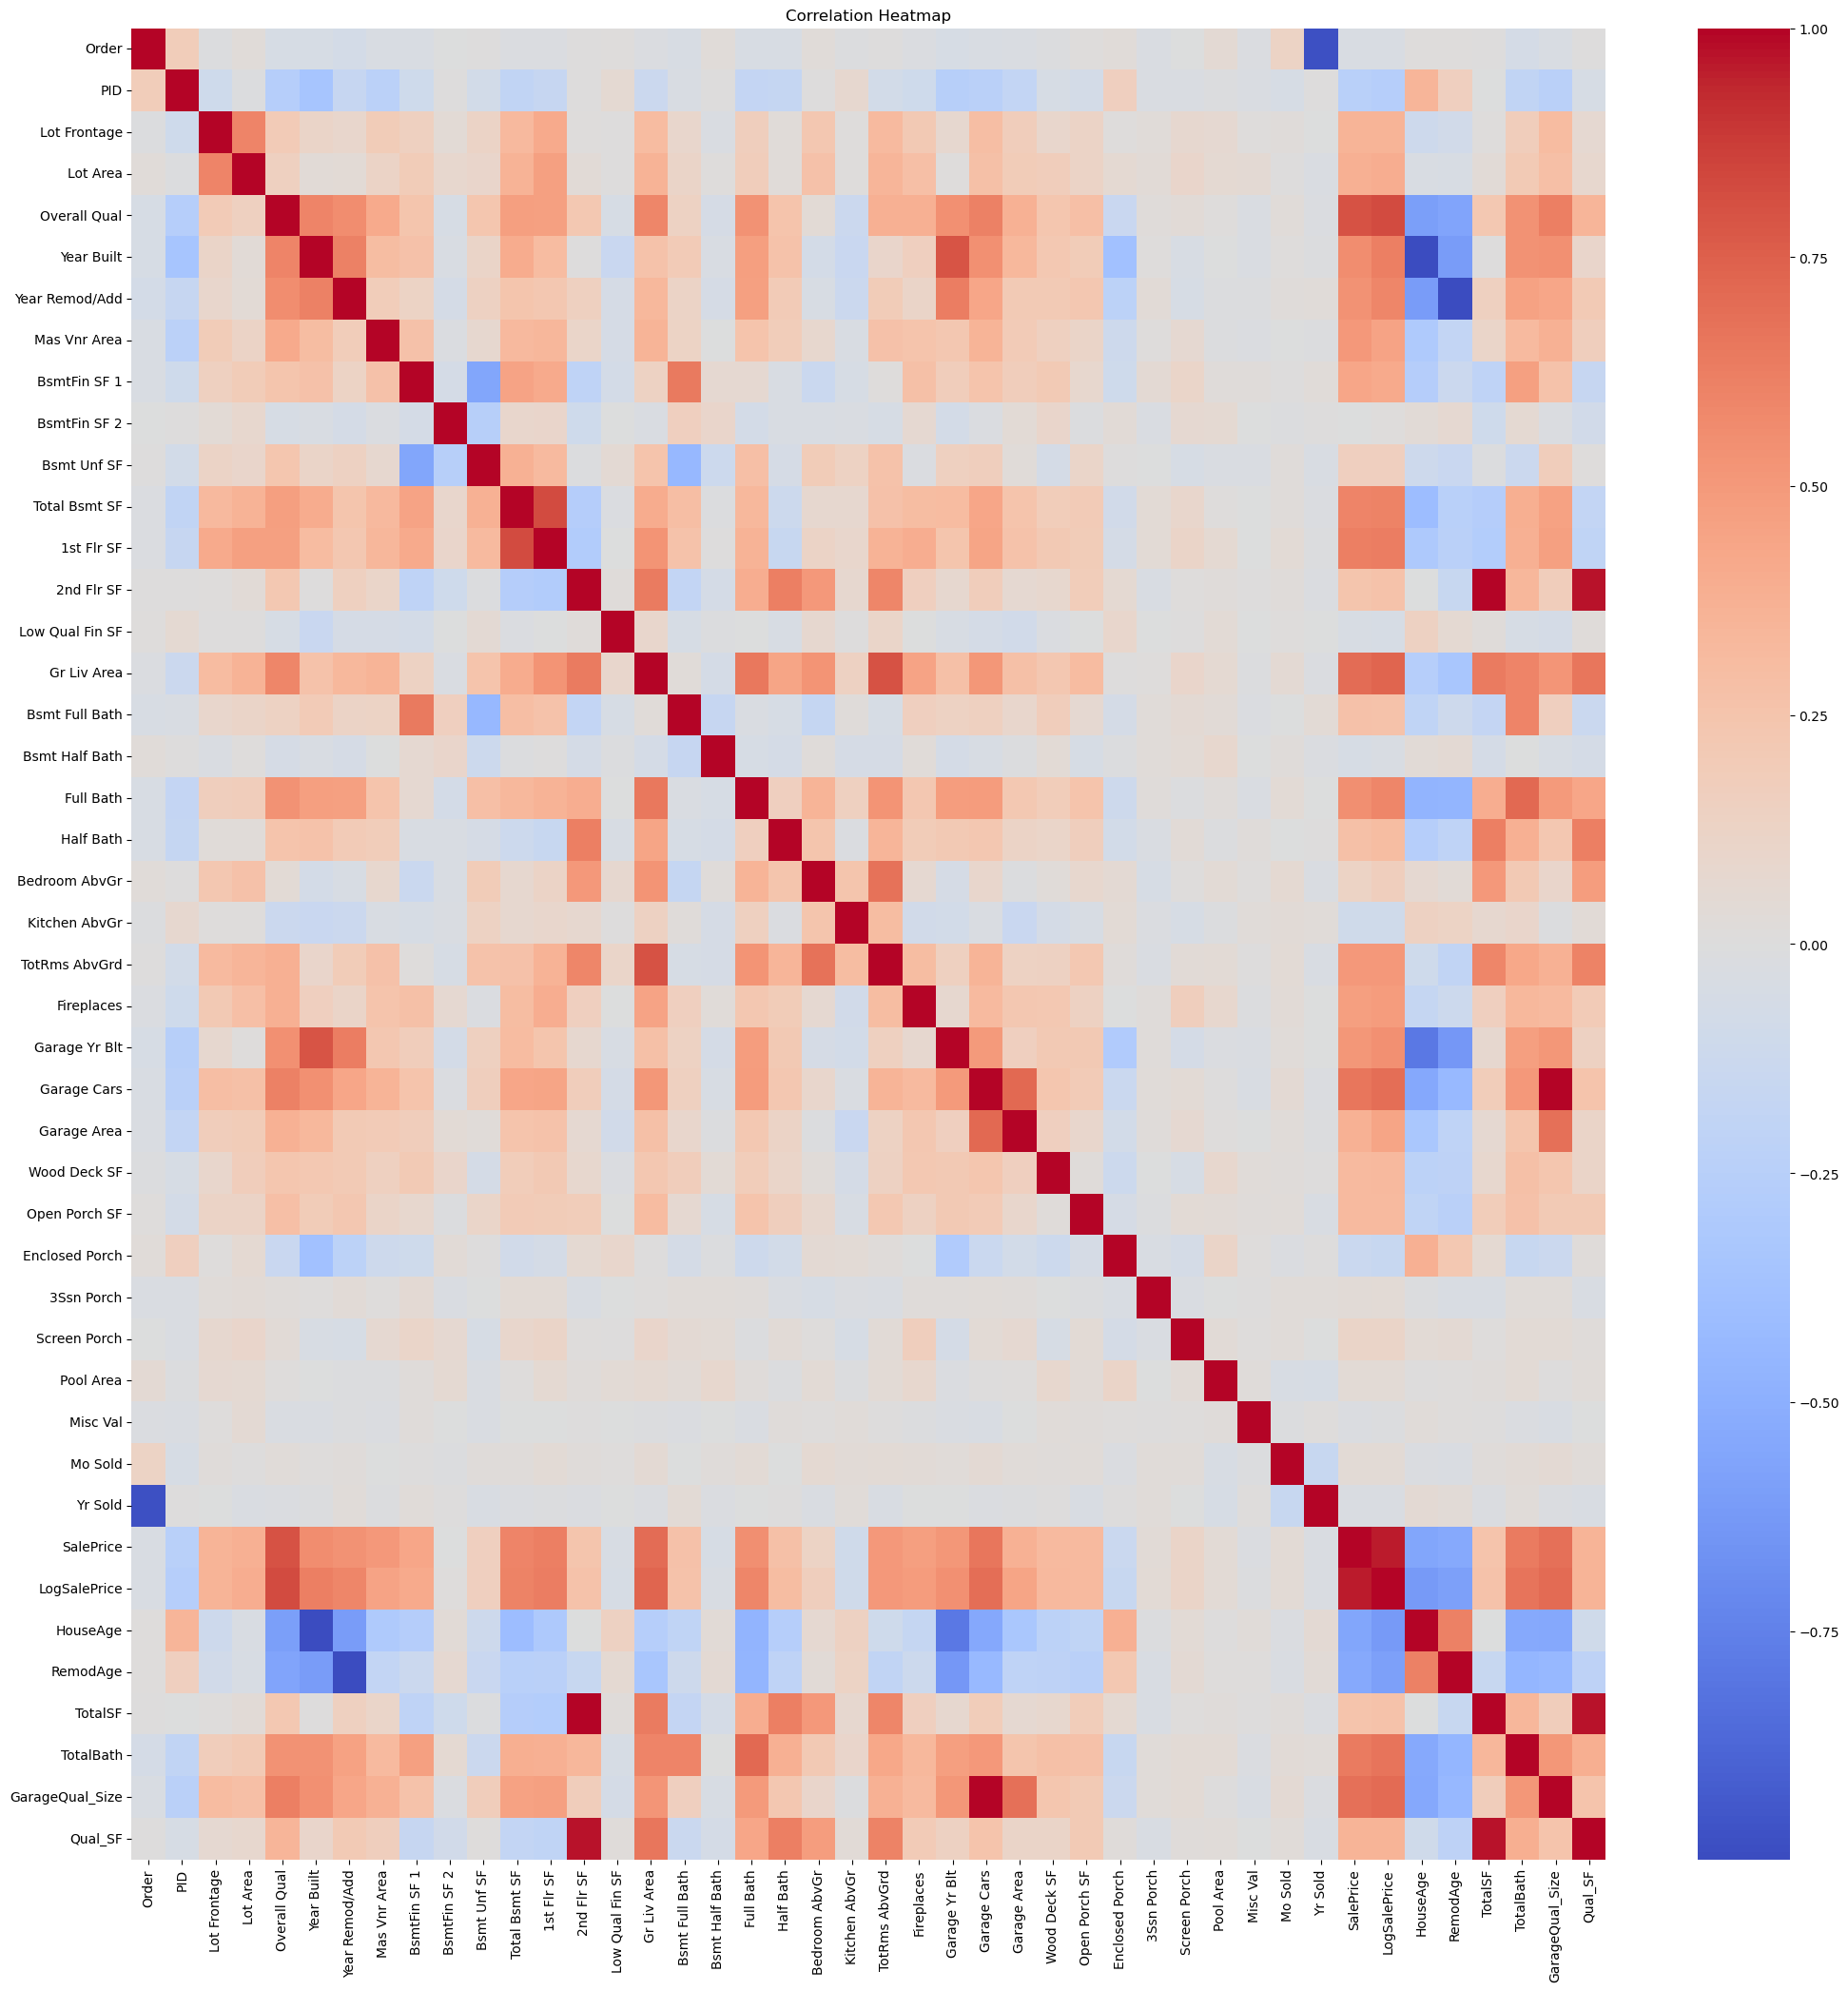

In [93]:
plt.figure(figsize=(25,25))

sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [94]:
strong_corr = top_features_eng[abs(top_features_eng) > 0.4]
print(strong_corr)

strong_corr = strong_corr.drop(
    index=["SalePrice", "LogSalePrice"],
    columns=["SalePrice", "LogSalePrice"],
    errors="ignore"
    
    
)


print('\n',strong_corr)

SalePrice          1.000000
LogSalePrice       0.955882
Overall Qual       0.803204
Gr Liv Area        0.701562
GarageQual_Size    0.681590
Garage Cars        0.660783
TotalBath          0.633355
1st Flr SF         0.621050
Total Bsmt SF      0.596673
HouseAge           0.561473
Year Built         0.561155
Full Bath          0.552701
RemodAge           0.535658
Year Remod/Add     0.534116
Garage Yr Blt      0.512933
TotRms AbvGrd      0.507588
Mas Vnr Area       0.505058
Fireplaces         0.469812
BsmtFin SF 1       0.430920
Name: SalePrice, dtype: float64

 Overall Qual       0.803204
Gr Liv Area        0.701562
GarageQual_Size    0.681590
Garage Cars        0.660783
TotalBath          0.633355
1st Flr SF         0.621050
Total Bsmt SF      0.596673
HouseAge           0.561473
Year Built         0.561155
Full Bath          0.552701
RemodAge           0.535658
Year Remod/Add     0.534116
Garage Yr Blt      0.512933
TotRms AbvGrd      0.507588
Mas Vnr Area       0.505058
Fireplaces    

In [95]:
top_features = strong_corr.index[:20]

### Heatmap for multicollinearity handling

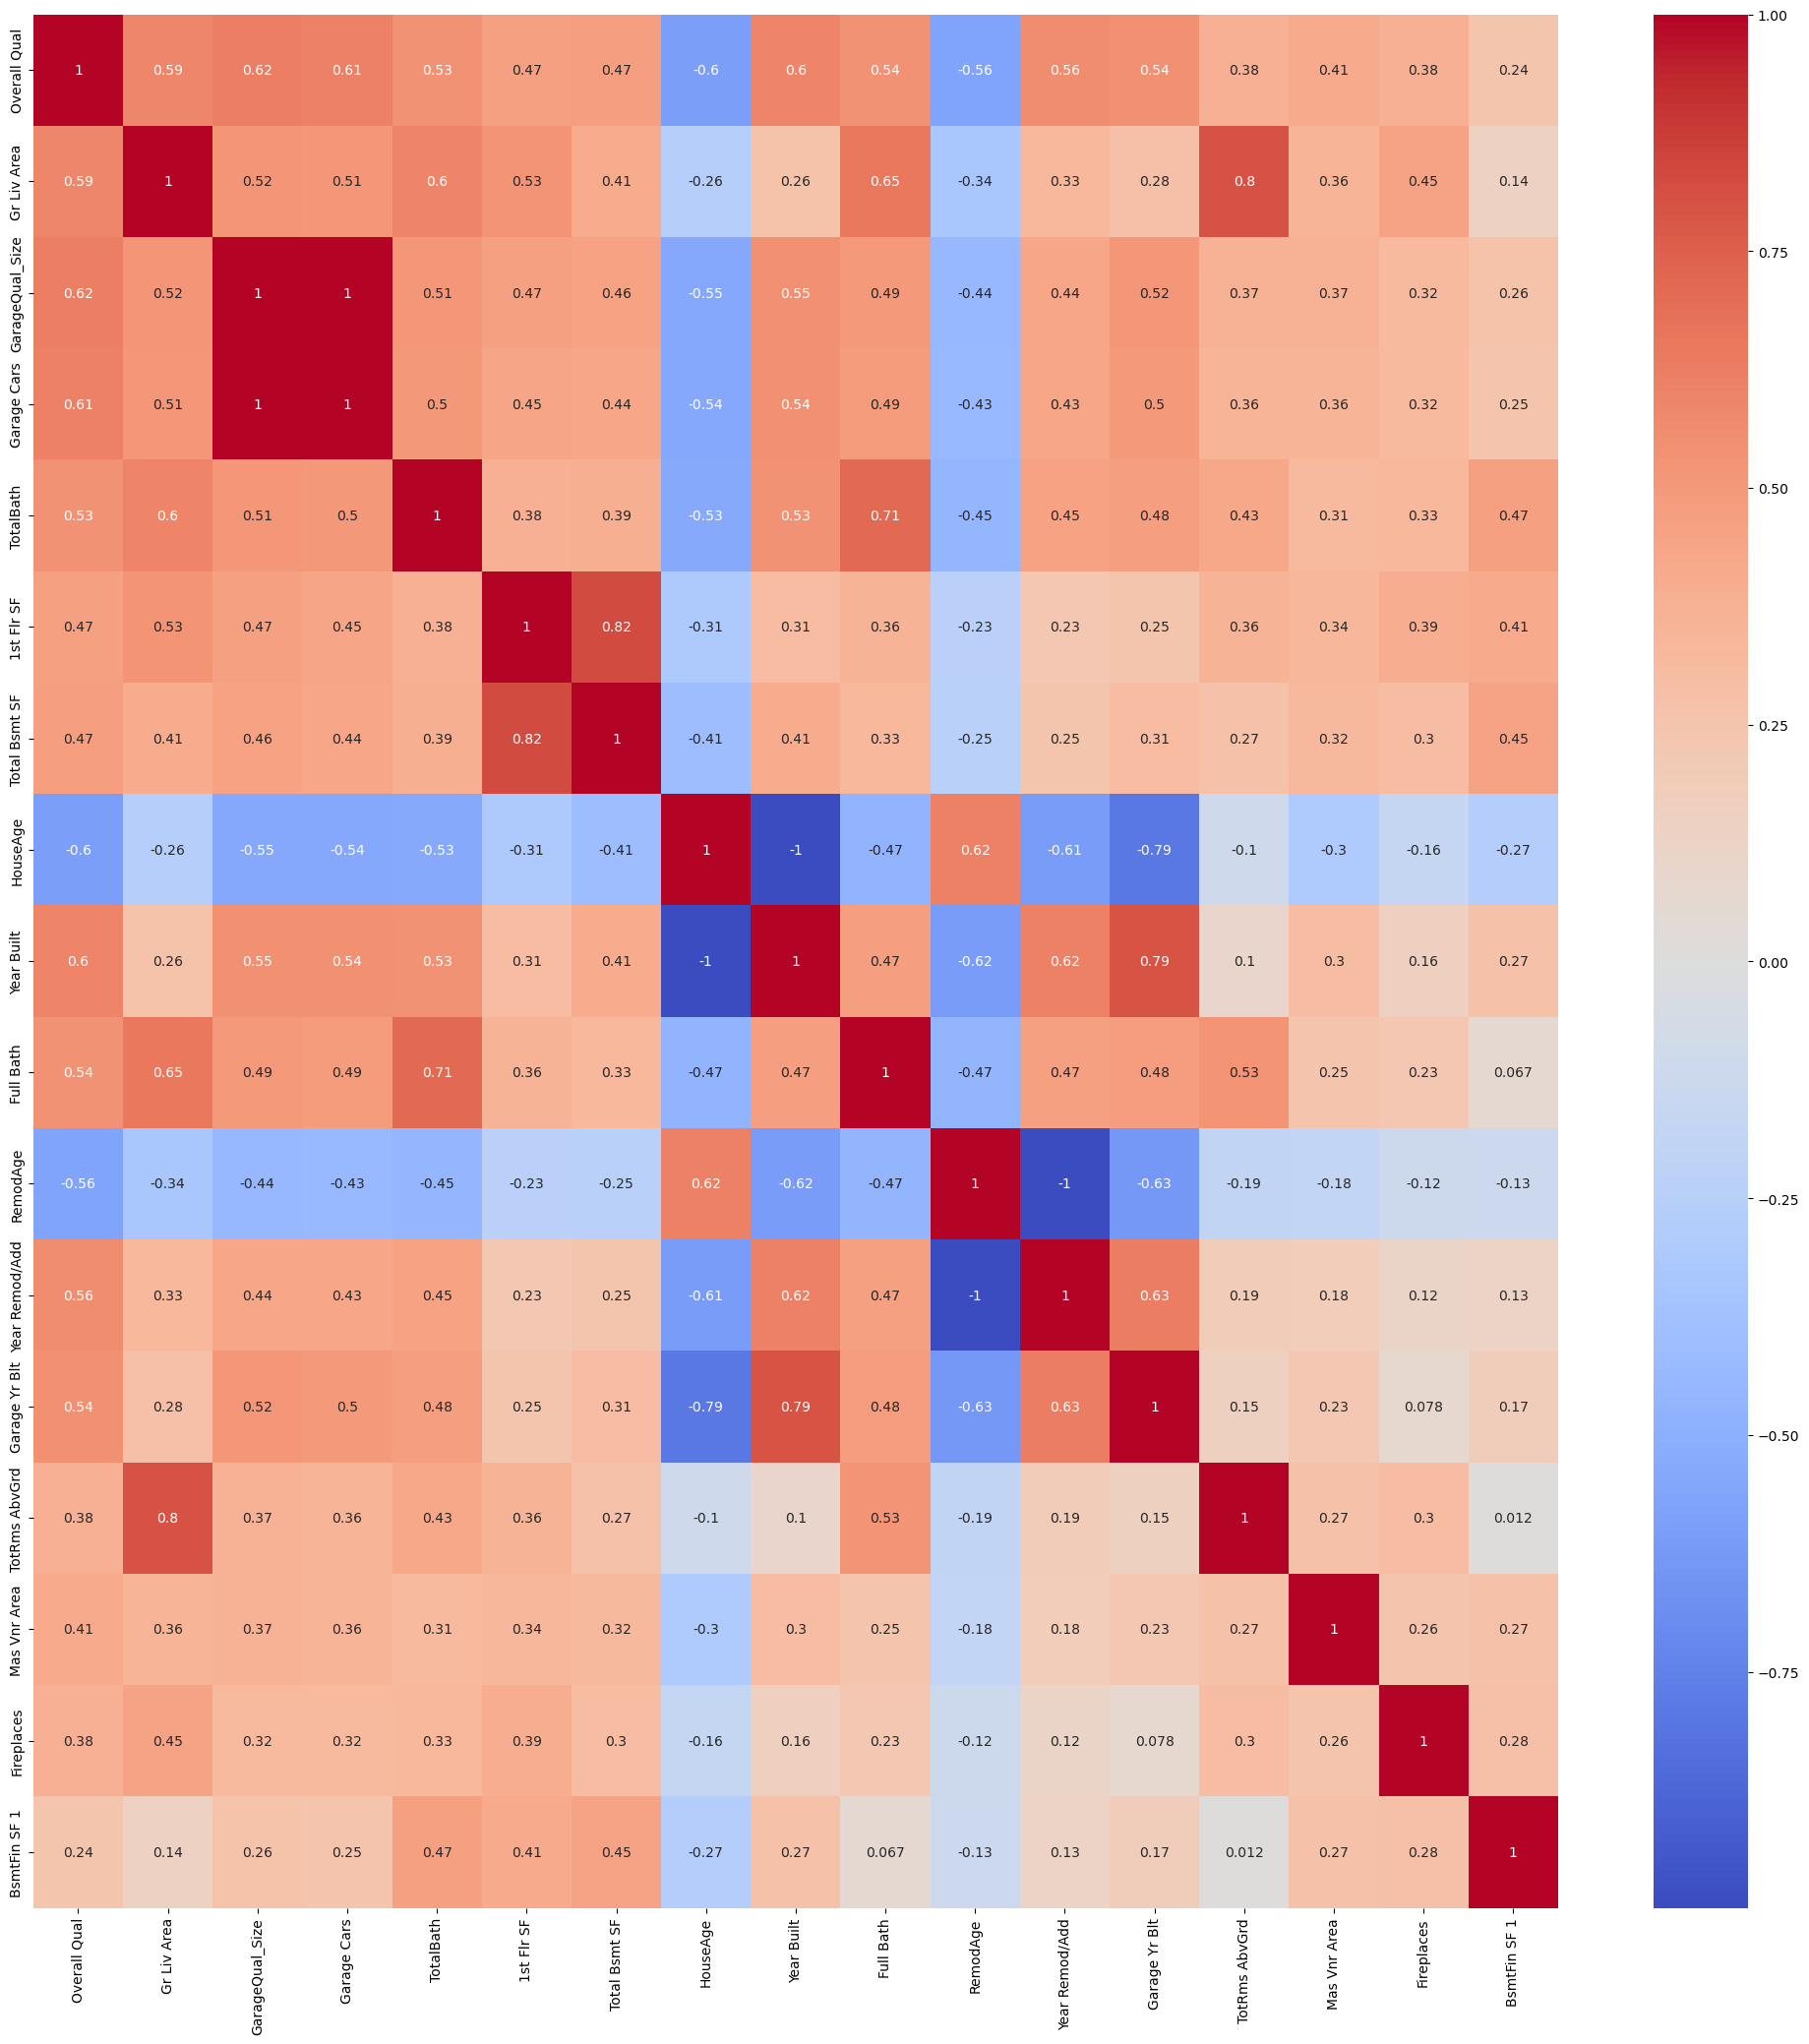

In [96]:
plt.figure(figsize=(25,25))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')
plt.show()

# Multicollinearity Control 


In [97]:
# Compute correlation matrix for selected features
corr_matrix = df[top_features].corr().abs()

# Create upper triangle matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns with correlation greater than threshold
threshold = 0.8
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Columns to drop due to multicollinearity:", to_drop)

# Drop them
df_reduced = df[top_features].drop(columns=to_drop)

print("Remaining features:", df_reduced.columns)


Columns to drop due to multicollinearity: ['Garage Cars', 'Total Bsmt SF', 'Year Built', 'Year Remod/Add', 'TotRms AbvGrd']
Remaining features: Index(['Overall Qual', 'Gr Liv Area', 'GarageQual_Size', 'TotalBath',
       '1st Flr SF', 'HouseAge', 'Full Bath', 'RemodAge', 'Garage Yr Blt',
       'Mas Vnr Area', 'Fireplaces', 'BsmtFin SF 1'],
      dtype='object')


In [98]:
top_features

Index(['Overall Qual', 'Gr Liv Area', 'GarageQual_Size', 'Garage Cars',
       'TotalBath', '1st Flr SF', 'Total Bsmt SF', 'HouseAge', 'Year Built',
       'Full Bath', 'RemodAge', 'Year Remod/Add', 'Garage Yr Blt',
       'TotRms AbvGrd', 'Mas Vnr Area', 'Fireplaces', 'BsmtFin SF 1'],
      dtype='object')

In [99]:
num_features = df.select_dtypes(include=['int64','float64']).columns.tolist()

t_features = ['Overall Qual', 'Gr Liv Area', 'GarageQual_Size', 'Garage Cars',
       'TotalBath', '1st Flr SF', 'HouseAge', 'Year Built', 'Full Bath',
       'RemodAge', 'Year Remod/Add', 'Garage Yr Blt', 'Mas Vnr Area',
       'TotRms AbvGrd', 'Fireplaces', 'BsmtFin SF 1']

features_to_drop = list(set(num_features)-set(t_features))
features_to_drop.append(to_drop)

print(features_to_drop)




['Wood Deck SF', 'Garage Area', 'Enclosed Porch', '2nd Flr SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Yr Sold', 'PID', 'Low Qual Fin SF', 'Bsmt Unf SF', 'Screen Porch', 'BsmtFin SF 2', 'Lot Frontage', 'Kitchen AbvGr', 'TotalSF', 'SalePrice', 'Mo Sold', 'Pool Area', 'Open Porch SF', 'Order', 'Half Bath', '3Ssn Porch', 'Lot Area', 'Qual_SF', 'Bedroom AbvGr', 'Bsmt Half Bath', 'Misc Val', 'LogSalePrice', ['Garage Cars', 'Total Bsmt SF', 'Year Built', 'Year Remod/Add', 'TotRms AbvGrd']]


In [100]:
df_encoded = pd.get_dummies(df, columns=object_cols_list, drop_first=True)

In [101]:
df_encoded.to_csv('AmesHousing_clean.csv', index=False)  # cleaned data in a file